<a href="https://colab.research.google.com/github/benhidalgov/Mineriadedatos/blob/main/Entrega_3_mineria_de_datos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploración y Preprocesamiento de Datos (EPL Dataset)
Este notebook replica la fase de Análisis Exploratorio de Datos (EDA) y preprocesamiento de variables para el dataset de la English Premier League (`epl_final.csv`).

**Objetivos:**
- Cargar los datos y revisar la estructura del dataset.
- Realizar un mapeo sistemático de los tipos de datos.
- Aplicar técnicas de codificación para variables categóricas de alta y baja cardinalidad.
- Visualizar relaciones y distribuciones clave.

In [ ]:
# Instalar category_encoders si no esta instalado (comun en Google Colab)
try:
    import category_encoders as ce
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "category-encoders"])
    import category_encoders as ce

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    silhouette_score
)



In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)



In [ ]:
# Carga de datos con fallback interactivo para Google Colab
try:
    df = pd.read_csv("epl_final.csv") # creamos un dataframe llamado df y cargamos el dataset csv
except FileNotFoundError:
    print("No se encontro 'epl_final.csv' en el directorio actual.")
    try:
        from google.colab import files
        print("Entorno Google Colab detectado. Por favor selecciona y sube 'epl_final.csv':")
        uploaded = files.upload()
        df = pd.read_csv("epl_final.csv")
    except ImportError:
        raise FileNotFoundError("Por favor coloca 'epl_final.csv' en el mismo directorio del notebook.")



### 1. Inspección Inicial del Dataset
El siguiente bloque carga las primeras filas para observar la estructura general del dataset, los nombres de las columnas y el formato de los datos que contiene.

In [ ]:
df.head() # visualizamos las primeras 5 filas



,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,17,8,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,17,12,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,6,16,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,6,13,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,17,12,8,6,6,4,21,20,1,3,0,0


**Interpretación:** La función `head()` nos permite confirmar que los datos se han cargado correctamente. Podemos observar columnas categóricas (como equipos y resultados) y numéricas (como goles y tiros). A continuación vemos las últimas filas con `tail()`.

In [ ]:
df.tail()# visualizamos las ultimas 5 filas



,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,12,14,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,5,13,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,11,7,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,17,11,7,2,3,6,10,11,2,2,0,0
9379,2024/25,2025-05-05,Crystal Palace,Nott'm Forest,1,1,D,0,0,D,20,12,3,4,7,4,9,15,3,8,0,0


**Interpretación:** `tail()` nos muestra el final del dataset, confirmando que la estructura se mantiene consistente hasta el último registro.

In [ ]:
df.shape #devuelve la cantidad de filas y columnas respectivamente



(9380, 22)

### 2. Dimensión y Tipos de Datos
Conocer el tamaño del dataset es crucial para entender la cantidad de información disponible. La función `shape` nos dirá filas y columnas.

In [ ]:
df.dtypes #observamos la columna y sus tipos de datos



,0
Season,object
MatchDate,object
HomeTeam,object
AwayTeam,object
FullTimeHomeGoals,int64
FullTimeAwayGoals,int64
FullTimeResult,object
HalfTimeHomeGoals,int64
HalfTimeAwayGoals,int64
HalfTimeResult,object


**Interpretación:** El resultado de `shape` nos indica que tenemos 9380 observaciones (filas) y 22 características (columnas). A continuación usamos `dtypes` para analizar qué tipo de dato informático asignó Pandas a cada columna y `isnull().sum()` para verificar nulos.

In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna // no notamos nulos en este dataset



,0
Season,0
MatchDate,0
HomeTeam,0
AwayTeam,0
FullTimeHomeGoals,0
FullTimeAwayGoals,0
FullTimeResult,0
HalfTimeHomeGoals,0
HalfTimeAwayGoals,0
HalfTimeResult,0


**Interpretación (`dtypes` y `isnull()`):**
- **Tipos de datos informáticos:** Pandas asignó tipo `object` a las variables categóricas (cadenas de texto como `HomeTeam`, `FullTimeResult`) y tipo `int64` a las variables numéricas (como `HomeShots`). Esto es correcto ya que los goles, tiros, tarjetas, etc. son valores discretos que no requieren decimales.
- **Valores nulos:** La función `isnull().sum()` confirma que **no hay valores nulos** en ninguna de las columnas, por lo que no es necesario aplicar técnicas de imputación.

---
### 3. Mapeo de Datos de las Columnas
Por buena práctica, definimos a continuación la naturaleza de cada variable (clasificación estadística y tipo de dato informático):

| Variable | Tipo de Dato (Pandas) | Clasificación Estadística |
| :--- | :--- | :--- |
| `Season` | object | Categórico Ordinal / Nominal |
| `MatchDate` | object | Categórico (Fecha) |
| `HomeTeam`, `AwayTeam` | object | Categórico Nominal |
| `FullTimeResult`, `HalfTimeResult` | object | Categórico Nominal |
| `FullTimeHomeGoals`, `FullTimeAwayGoals` | int64 | Numérico Discreto |
| `HalfTimeHomeGoals`, `HalfTimeAwayGoals` | int64 | Numérico Discreto |
| `HomeShots`, `AwayShots` | int64 | Numérico Discreto |
| `HomeShotsOnTarget`, `AwayShotsOnTarget` | int64 | Numérico Discreto |
| `HomeCorners`, `AwayCorners` | int64 | Numérico Discreto |
| `HomeFouls`, `AwayFouls` | int64 | Numérico Discreto |
| `HomeYellowCards`, `AwayYellowCards` | int64 | Numérico Discreto |
| `HomeRedCards`, `AwayRedCards` | int64 | Numérico Discreto |
---

In [ ]:
cant_cat_col_hometeam_df = df['HomeTeam'].value_counts() # nos mostrará la cantidad de categoricas distintas unicas de HomeTeam
print(cant_cat_col_hometeam_df)
print(f"cantidad HomeTeam: {cant_cat_col_hometeam_df.count()}") # tenemos 46 categorias distintas de equipos



HomeTeam
Everton             471
Chelsea             469
Tottenham           469
Man United          469
Arsenal             468
Liverpool           467
Man City            450
Newcastle           430
West Ham            417
Aston Villa         412
Fulham              335
Southampton         318
Sunderland          266
Leicester           245
Crystal Palace      244
West Brom           244
Blackburn           204
Bolton              204
Wolves              204
Stoke               190
Middlesbrough       187
Burnley             171
Wigan               152
Brighton            151
Bournemouth         150
Watford             133
Swansea             133
Leeds               131
Norwich             131
Birmingham          130
Charlton            128
Portsmouth          128
Hull                 95
Sheffield United     76
Brentford            75
Reading              57
QPR                  57
Derby                57
Ipswich              55
Nott'm Forest        55
Huddersfield         38
Cardiff

In [ ]:
cant_cat_col_ftr_df = df['FullTimeResult'].value_counts() # nos mostrará la cantidad de categoricas distintas unicas de FullTimeResult
print(cant_cat_col_ftr_df)
print(f"cantidad FullTimeResult: {cant_cat_col_ftr_df.count()}")



FullTimeResult
H    4299
A    2768
D    2313
Name: count, dtype: int64
cantidad FullTimeResult: 3


**Interpretación Cardinalidad:** Comprobamos que hay 46 equipos únicos tanto para Local como Visitante, lo cual representa una **alta cardinalidad**. Para los resultados (`FullTimeResult`) solo hay 3 categorías únicas (H, D, A), lo que indica **baja cardinalidad**.

A continuación, usamos `describe()` para ver la estadística descriptiva de los valores numéricos del dataframe.

In [ ]:
df.describe()



,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


**Interpretación de `describe()`:** Podemos observar en los estadísticos que el promedio de goles del equipo local (`FullTimeHomeGoals`) es ligeramente superior al del equipo visitante (`FullTimeAwayGoals`), lo cual es consistente con la "ventaja de jugar en casa" en el fútbol. Las desviaciones estándar y rangos intercuartílicos son coherentes, sin valores máximos irracionales que indiquen outliers severos.

---
### 4. Codificación de Variables Categóricas (Encoding)
Los modelos de Machine Learning requieren datos matemáticos y no pueden procesar directamente variables de texto (object).

**Justificación One-Hot Encoding:** Usaremos **One-Hot Encoding** para los resultados (`FullTimeResult` y `HalfTimeResult`) porque tienen una **baja cardinalidad** (solo 3 categorías). Esto creará 3 columnas binarias sin asumir ningún orden de jerarquía o importancia.

In [ ]:
# 1. OneHot Encoding para 'FullTimeResult' y 'HalfTimeResult' (baja cardinalidad)
ohe = OneHotEncoder(sparse_output=False)
ftr_htr_encoded = ohe.fit_transform(df[['FullTimeResult', 'HalfTimeResult']])



In [ ]:
# Convertimos el resultado en un DataFrame con nombres de columnas claros
ftr_htr_df = pd.DataFrame(
    ftr_htr_encoded,
    columns=ohe.get_feature_names_out(['FullTimeResult', 'HalfTimeResult']),
    index=df.index
)



**Justificación Binary Encoding:** Usaremos **Binary Encoding** para `HomeTeam` y `AwayTeam`. Al tener una **alta cardinalidad** (46 equipos), usar One-Hot Encoding generaría un exceso de nuevas variables (92 columnas en total), causando un problema de dimensionalidad. Binary Encoding transforma las categorías a números binarios reduciendo de forma muy eficiente la cantidad de características nuevas generadas.

In [ ]:
# 2. Binary Encoding para 'HomeTeam' y 'AwayTeam' usando Category Encoders
# Este encoder es ideal para columnas con alta cardinalidad como los equipos (46 categorias)
be = ce.BinaryEncoder(cols=['HomeTeam', 'AwayTeam'])
df_binary = be.fit_transform(df[['HomeTeam', 'AwayTeam']])



In [ ]:
# 3. Concatenar todo y eliminar las columnas originales categoricas
# Unimos el dataframe original con las nuevas columnas
cols_to_drop = ['FullTimeResult', 'HalfTimeResult', 'HomeTeam', 'AwayTeam', 'Season', 'MatchDate']
df_final = pd.concat([df.drop(columns=cols_to_drop), ftr_htr_df, df_binary], axis=1)



**Interpretación Concatenación:** Hemos creado exitosamente `df_final` eliminando las columnas originales categóricas y concatenando las nuevas representaciones numéricas generadas por los dos encoders.

In [ ]:
# 4. Ver los cambios
print(df_final.head())
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")



   FullTimeHomeGoals  FullTimeAwayGoals  HalfTimeHomeGoals  HalfTimeAwayGoals  \
0                  4                  0                  2                  0   
1                  4                  2                  1                  0   
2                  1                  3                  1                  1   
3                  2                  2                  1                  2   
4                  2                  0                  2                  0   

   HomeShots  AwayShots  HomeShotsOnTarget  AwayShotsOnTarget  HomeCorners  \
0         17          8                 14                  4            6   
1         17         12                 10                  5            7   
2          6         16                  3                  9            8   
3          6         13                  4                  6            5   
4         17         12                  8                  6            6   

   AwayCorners  HomeFouls  AwayFouls  HomeYe

**Interpretación de Codificación Final:** Como podemos observar en el output, todas las características están ahora convertidas a variables numéricas y están listas para ser ingresadas a algoritmos de Machine Learning. El número total de columnas aumentó, pero de forma controlada.

---
### 5. Análisis Visual (EDA Visual)
El siguiente bloque crea gráficas para interpretar el comportamiento de la liga y la relación entre las variables generadas.

In [ ]:
# Visualización de Datos (Gráficas)
# 1. Distribución de Resultados a Tiempo Completo (FullTimeResult)
# H = Home Win (Victoria del local), A = Away Win (Victoria del visitante), D = Draw(Empate)



In [ ]:
plt.figure(figsize=(8, 5))
# Creamos una copia de la columna temporalmente y le cambiamos los nombres (apodos)
resultados_nombres = df['FullTimeResult'].map({
    'H': 'Victoria Local',
    'D': 'Empate',
    'A': 'Victoria Visitante'
})




<Figure size 800x500 with 0 Axes>

/tmp/ipykernel_737/1241310621.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=resultados_nombres, palette='viridis')


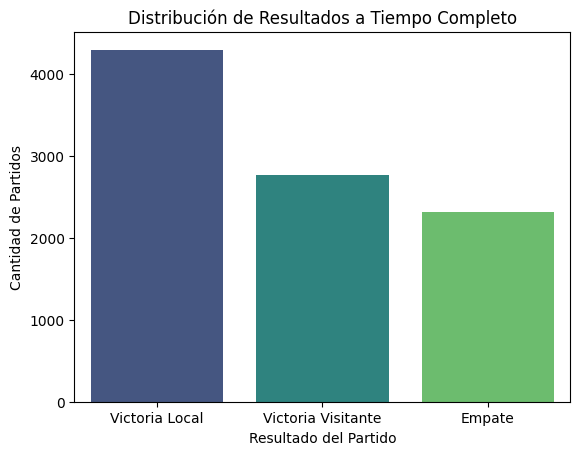

In [ ]:
sb.countplot(x=resultados_nombres, palette='viridis')
plt.title('Distribución de Resultados a Tiempo Completo')
plt.xlabel('Resultado del Partido')
plt.ylabel('Cantidad de Partidos')
plt.show()



**Interpretación (Distribución de Resultados):** El gráfico de barras confirma visualmente que la **Victoria Local** es el resultado más frecuente en la liga de forma histórica, seguido de la victoria del visitante y por último el empate. Esto demuestra que la variable a predecir no está perfectamente balanceada.

/tmp/ipykernel_737/2534016653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df, x='FullTimeHomeGoals', y='HomeShotsOnTarget', palette='Reds')


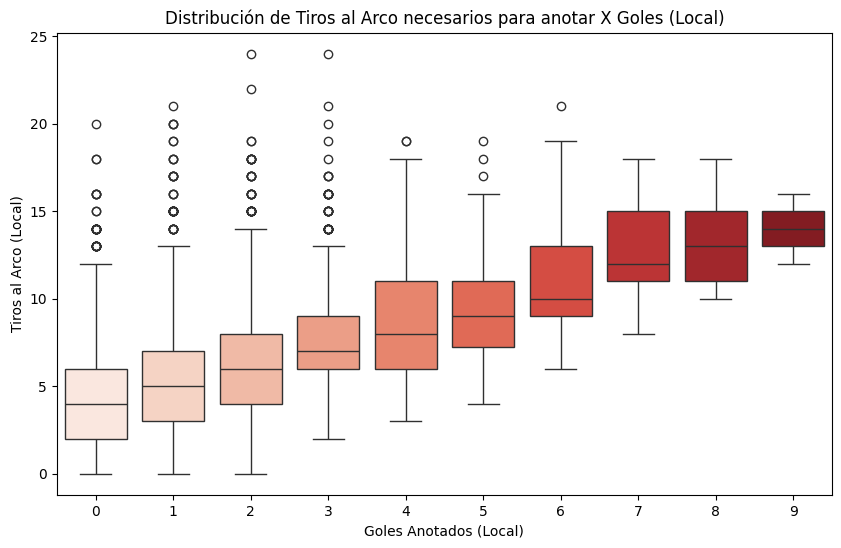

In [ ]:
# 3. Relación entre Tiros al Arco del Local y Goles del Local
plt.figure(figsize=(10, 6))
sb.boxplot(data=df, x='FullTimeHomeGoals', y='HomeShotsOnTarget', palette='Reds')
plt.title('Distribución de Tiros al Arco necesarios para anotar X Goles (Local)')
plt.xlabel('Goles Anotados (Local)')
plt.ylabel('Tiros al Arco (Local)')
plt.show()



**Interpretación (Goles vs Tiros al Arco):** Este gráfico de cajas (boxplot) ilustra que, como dicta la lógica, a mayor número de goles anotados, suele ser necesario un mayor número de tiros al arco. Muestra muy claramente el rango (cuartiles) de tiros necesarios por un equipo local para conseguir 1, 2, 3 o más goles, así como algunos valores atípicos (equipos que anotaron mucho con pocos tiros o viceversa).

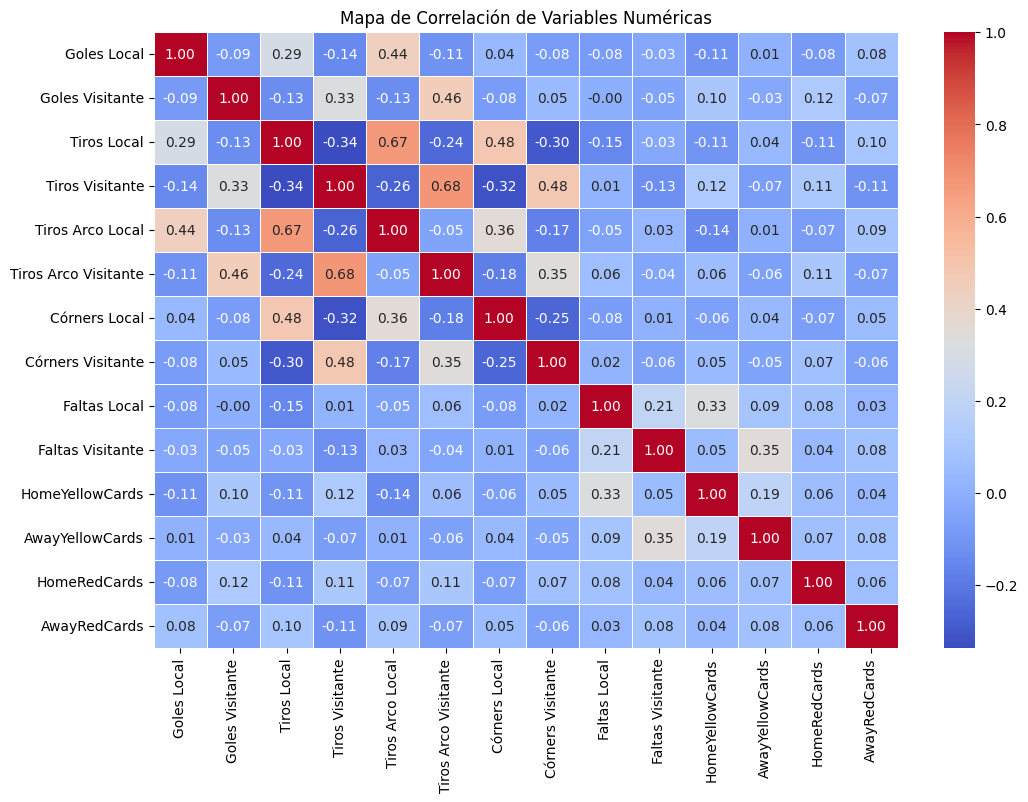

In [ ]:
# Diccionario para traducir los nombres a español en la gráfica
nombres_espanol = {
    'FullTimeHomeGoals': 'Goles Local',
    'FullTimeAwayGoals': 'Goles Visitante',
    'HomeShots': 'Tiros Local',
    'AwayShots': 'Tiros Visitante',
    'HomeShotsOnTarget': 'Tiros Arco Local',
    'AwayShotsOnTarget': 'Tiros Arco Visitante',
    'HomeCorners': 'Córners Local',
    'AwayCorners': 'Córners Visitante',
    'HomeFouls': 'Faltas Local',
    'AwayFouls': 'Faltas Visitante'
}

num_cols = [
    'FullTimeHomeGoals', 'FullTimeAwayGoals', 'HomeShots', 'AwayShots',
    'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners',
    'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards',
    'HomeRedCards', 'AwayRedCards'
]

plt.figure(figsize=(12, 8))
correlation_matrix = df[num_cols].corr().rename(index=nombres_espanol, columns=nombres_espanol)

sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlación de Variables Numéricas')
plt.show()



**Interpretación (Matriz de Correlación):** El mapa de calor (heatmap) mide la fuerza de la relación lineal entre variables numéricas. Podemos observar altas correlaciones positivas entre eventos lógicos: tiros a puerta (`Tiros Arco Local`) y goles marcados (`Goles Local`). Las correlaciones entre eventos del equipo local y eventos del visitante suelen ser cercanas a cero, lo que implica que lo que hace uno no dictamina estrictamente el total del otro.

/tmp/ipykernel_737/4029513543.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=top_10_teams.values, y=top_10_teams.index, palette='magma')


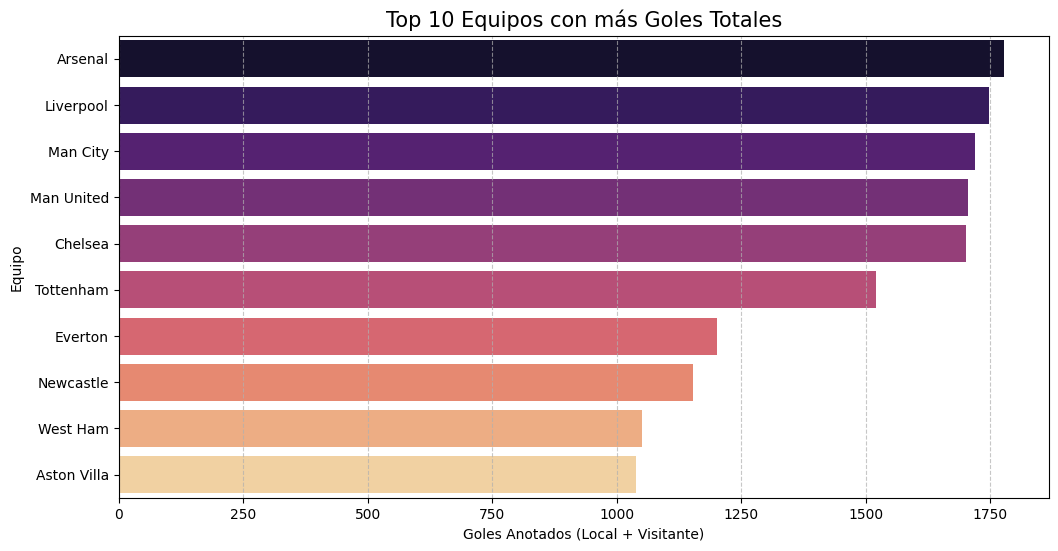

In [ ]:
# 1. Preparación de datos por equipo
# Sumamos goles anotados como local y como visitante para cada equipo
home_goals = df.groupby('HomeTeam')['FullTimeHomeGoals'].sum()
away_goals = df.groupby('AwayTeam')['FullTimeAwayGoals'].sum()
total_goals = (home_goals + away_goals).sort_values(ascending=False)

# Seleccionamos el Top 10
top_10_teams = total_goals.head(10)

# 2. Visualización: Top 10 Equipos más Goleadores
plt.figure(figsize=(12, 6))
sb.barplot(x=top_10_teams.values, y=top_10_teams.index, palette='magma')
plt.title('Top 10 Equipos con más Goles Totales', fontsize=15)
plt.xlabel('Goles Anotados (Local + Visitante)')
plt.ylabel('Equipo')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



**Interpretación (Top 10 Goleadores):** La gráfica de barras muestra horizontalmente a los 10 equipos más prolíficos de la liga, combinando su desempeño. Esto permite identificar rápidamente las franquicias que tienen mayor "peso" ofensivo en la Premier League.

A continuación, analizaremos la distribución de frecuencia para estos mismos equipos top 10 jugando de local (para revisar si sus goles totales se deben a rachas puntuales o si mantienen un promedio consistente).

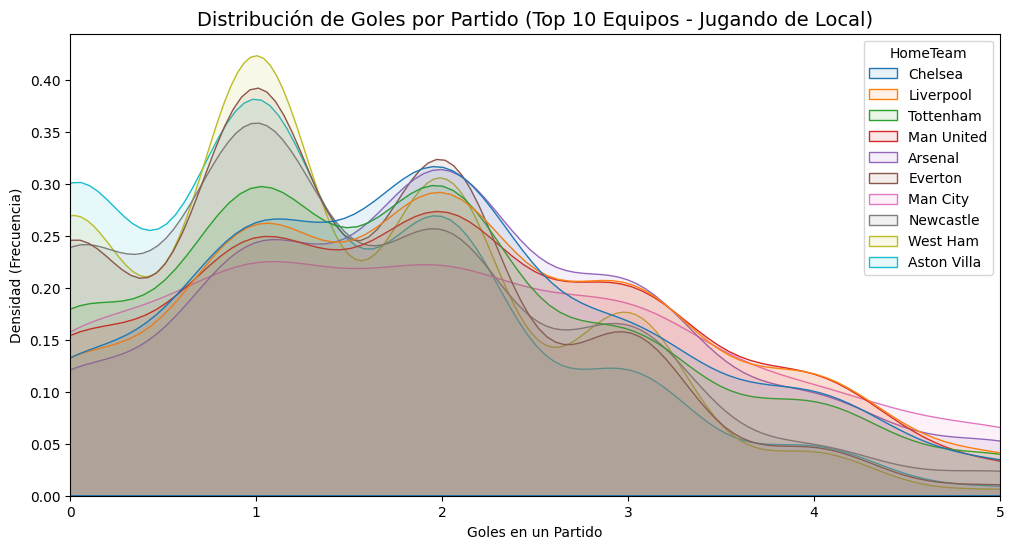

In [ ]:
# 3. Análisis de Consistencia (Skeptical Check)
# ¿El Top 10 es consistente o depende de rachas?
# Filtramos el dataframe original para tener solo partidos de estos 10 equipos
df_top10 = df[df['HomeTeam'].isin(top_10_teams.index)]

plt.figure(figsize=(12, 6))
sb.kdeplot(data=df_top10, x='FullTimeHomeGoals', hue='HomeTeam', common_norm=False, fill=True, alpha=0.1)
plt.title('Distribución de Goles por Partido (Top 10 Equipos - Jugando de Local)', fontsize=14)
plt.xlabel('Goles en un Partido')
plt.ylabel('Densidad (Frecuencia)')
plt.xlim(0, 5) # Limitamos a 6 goles para ver mejor la masa de datos
plt.show()



**Interpretación Final (Densidad de Goles - Top 10):** El gráfico de densidad revela que incluso los equipos más goleadores tienen su curva centrada entre 1 y 2 goles por partido. La extensión de la curva hacia la derecha nos muestra la varianza de equipos de élite, demostrando que aunque todos pertenezcan al Top 10, algunos tienen una mayor probabilidad matemática de lograr goleadas (3, 4 o más goles) en comparación con el resto.

---
# Seccion 2 - Modelado, Justificacion Tecnica y Analisis de Resultados

En esta seccion aplicamos tres tipos de modelos supervisados al dataset EPL, justificamos su eleccion y analizamos los resultados obtenidos.

| Modelo | Tipo de problema | Variable objetivo |
| :--- | :--- | :--- |
| Regresion Lineal | Predictivo / Regresion | `FullTimeHomeGoals` (numerico) |
| Arbol de Decision (Clasificacion) | Predictivo / Clasificacion | `FullTimeResult` (H, D, A) |
| Naive Bayes Gaussiano | Predictivo / Clasificacion | `FullTimeResult` (H, D, A) |

## 1. Seleccion de Modelos y Preprocesamiento

### Justificacion de la seleccion

**Regresion Lineal** -- Elegimos predecir `FullTimeHomeGoals` (una variable cuantitativa discreta) a partir de atributos numericos del partido (tiros al arco, corners, faltas, etc.). La regresion lineal es el punto de partida natural para este tipo de problema porque permite estimar el valor esperado de la variable objetivo como combinacion lineal de las entradas y exponer el coeficiente (peso) de cada predictor.

**Arbol de Decision (Clasificacion)** -- El resultado del partido (`FullTimeResult`: H, D, A) es una variable categorica con tres clases. Los arboles de decision son ideales porque generan reglas de decision disjuntas e interpretables (ej.: si los tiros al arco del local > 7 y los corners > 5 => Victoria Local), permitiendo entender *por que* se predice cada clase.

**Naive Bayes Gaussiano** -- Complementamos el arbol con Naive Bayes, que es practico cuando existe incertidumbre y se desean probabilidades de pertenencia a cada clase. Asume independencia condicional entre predictores (hipotesis 'ingenua'), lo que lo hace muy rapido y sirve como baseline probabilistico robusto.



In [ ]:
# Preprocesamiento comun

# 1. Mapeo de variables categoricas de baja cardinalidad (Label Encoding)
result_map = {'H': 0, 'D': 1, 'A': 2}
df['FullTimeResult_enc']  = df['FullTimeResult'].map(result_map)
df['HalfTimeResult_enc']  = df['HalfTimeResult'].map(result_map)

# 2. Binary Encoding para equipos (alta cardinalidad: 46 equipos unicos)
# Justificacion: One-Hot generaria 92 columnas extra (2x46).
# Binary Encoding usa solo log2(46) ~ 6 columnas por variable => mucho mas eficiente.
enc = ce.BinaryEncoder(cols=['HomeTeam', 'AwayTeam'])
df_enc = enc.fit_transform(df)

# 3. Eliminar columnas no numericas que quedan tras la codificacion
cols_to_drop = ['Season', 'MatchDate', 'FullTimeResult', 'HalfTimeResult']
df_enc = df_enc.drop(columns=cols_to_drop, errors='ignore')

# 4. Traducir nombres de columnas al español
diccionario_columnas = {
    'HomeShots': 'Tiros_Local',
    'HomeShotsOnTarget': 'Tiros_Arco_Local',
    'HomeCorners': 'Corners_Local',
    'HomeFouls': 'Faltas_Local',
    'HomeYellowCards': 'Tarjetas_Amarillas_Local',
    'HomeRedCards': 'Tarjetas_Rojas_Local',
    'AwayShots': 'Tiros_Visitante',
    'AwayShotsOnTarget': 'Tiros_Arco_Visitante',
    'AwayCorners': 'Corners_Visitante',
    'AwayFouls': 'Faltas_Visitante',
    'AwayYellowCards': 'Tarjetas_Amarillas_Visitante',
    'AwayRedCards': 'Tarjetas_Rojas_Visitante',
    'FullTimeHomeGoals': 'Goles_Local',
    'FullTimeAwayGoals': 'Goles_Visitante',
    'HalfTimeHomeGoals': 'Goles_MedioTiempo_Local',
    'HalfTimeAwayGoals': 'Goles_MedioTiempo_Visitante',
    'FullTimeResult_enc': 'Resultado_Final_enc',
    'HalfTimeResult_enc': 'Resultado_MedioTiempo_enc'
}

# Traducimos tambien las columnas binarias de equipos
for col in df_enc.columns:
    if col.startswith('HomeTeam_'):
        diccionario_columnas[col] = col.replace('HomeTeam_', 'EquipoLocal_')
    elif col.startswith('AwayTeam_'):
        diccionario_columnas[col] = col.replace('AwayTeam_', 'EquipoVisitante_')

df_enc = df_enc.rename(columns=diccionario_columnas)

print('Dimensiones tras preprocesamiento:', df_enc.shape)
print('Columnas:', df_enc.columns.tolist())



Dimensiones tras preprocesamiento: (9380, 30)
Columnas: ['EquipoLocal_0', 'EquipoLocal_1', 'EquipoLocal_2', 'EquipoLocal_3', 'EquipoLocal_4', 'EquipoLocal_5', 'EquipoVisitante_0', 'EquipoVisitante_1', 'EquipoVisitante_2', 'EquipoVisitante_3', 'EquipoVisitante_4', 'EquipoVisitante_5', 'Goles_Local', 'Goles_Visitante', 'Goles_MedioTiempo_Local', 'Goles_MedioTiempo_Visitante', 'Tiros_Local', 'Tiros_Visitante', 'Tiros_Arco_Local', 'Tiros_Arco_Visitante', 'Corners_Local', 'Corners_Visitante', 'Faltas_Local', 'Faltas_Visitante', 'Tarjetas_Amarillas_Local', 'Tarjetas_Amarillas_Visitante', 'Tarjetas_Rojas_Local', 'Tarjetas_Rojas_Visitante', 'Resultado_Final_enc', 'Resultado_MedioTiempo_enc']


---
##Justificación Técnica: Regresión Lineal
Para predecir la cantidad de goles que anotará el equipo local (FullTimeHomeGoals), utilizamos un modelo de Regresión Lineal. Este modelo funciona como una fórmula matemática que intenta explicar cuántos goles se marcarán basándose en estadísticas clave, como los tiros a puerta, el total de tiros realizados y los tiros de esquina.

##¿Por qué elegimos este modelo?
La gran ventaja de la regresión lineal es su capacidad de interpretación. Cada variable predictora tiene un "peso" (coeficiente) que nos indica cuánto influye en el resultado final. Por ejemplo, al analizar los coeficientes, podemos responder preguntas concretas y fáciles de entender para cualquier persona, como: "¿Cuántos goles más se esperan si el equipo local logra hacer un tiro adicional a puerta?".

##Consideraciones importantes:
Al preparar los datos, tomamos una decisión fundamental: excluimos variables que ocurren después del evento. Por ejemplo, no usamos el resultado final del partido (FullTimeResult) ni los goles del visitante (FullTimeAwayGoals) para predecir los goles del local, porque son consecuencias del partido y no las causas. Incluirlas haría que el modelo "hiciera trampa", ya que intentaría predecir el marcador usando información que solo se conoce al finalizar el encuentro.

In [ ]:
# Regresion Lineal: predecir Goles_Local

target_reg = 'Goles_Local'

# Excluimos variables que son resultado del partido (data leakage)
exclude_reg = ['Goles_Local', 'Goles_Visitante', 'Resultado_Final_enc',
               'Goles_MedioTiempo_Local', 'Goles_MedioTiempo_Visitante', 'Resultado_MedioTiempo_enc']

features_reg = [c for c in df_enc.columns if c not in exclude_reg]
X_reg = df_enc[features_reg]
y_reg = df_enc[target_reg]

# Division 80/20 con semilla para reproducibilidad
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Entrenamiento
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)

# Predicciones y metricas
y_pred_r = lr.predict(X_test_r)
mse  = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_r, y_pred_r)
r2   = r2_score(y_test_r, y_pred_r)
n = len(y_test_r)
p = X_test_r.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f'ECM  (Error Cuadratico Medio):      {mse:.4f}')
print(f'RECM (Raiz del Error Cuadratico):   {rmse:.4f}  goles')
print(f'EAM  (Error Absoluto Medio):        {mae:.4f}  goles')
print(f'R2   (Coef. de Determinación):      {r2:.4f}')
print(f'R2 Ajustado:                        {adj_r2:.4f}')



ECM  (Error Cuadratico Medio):      1.3435
RECM (Raiz del Error Cuadratico):   1.1591  goles
EAM  (Error Absoluto Medio):        0.9007  goles
R2   (Coef. de Determinación):      0.2516
R2 Ajustado:                        0.2419


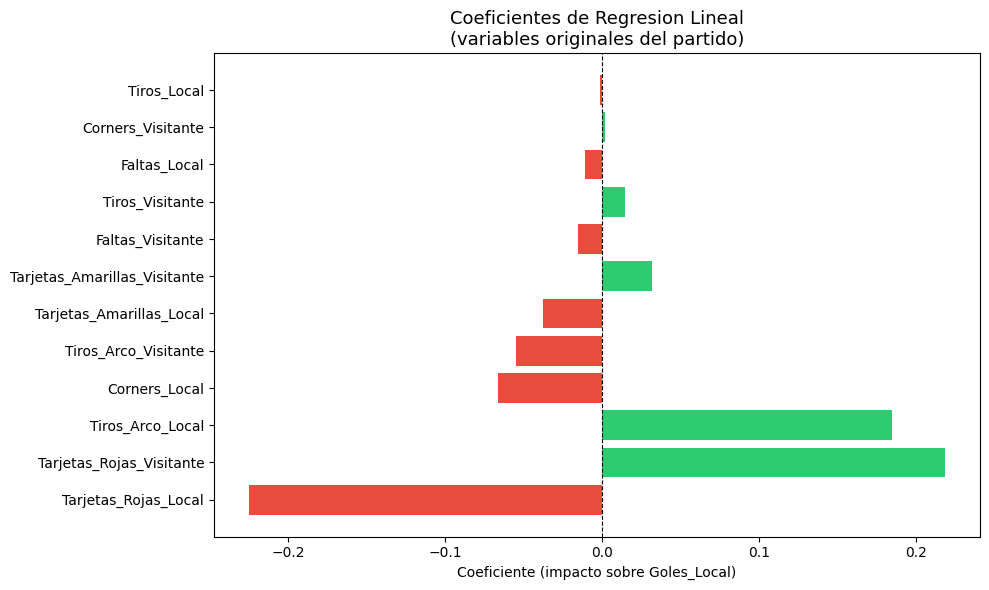

                    Variable  Coeficiente
        Tarjetas_Rojas_Local    -0.225334
    Tarjetas_Rojas_Visitante     0.218590
            Tiros_Arco_Local     0.184462
               Corners_Local    -0.066367
        Tiros_Arco_Visitante    -0.054781
    Tarjetas_Amarillas_Local    -0.037997
Tarjetas_Amarillas_Visitante     0.031741
            Faltas_Visitante    -0.015251
             Tiros_Visitante     0.014403
                Faltas_Local    -0.010892
           Corners_Visitante     0.001714
                 Tiros_Local    -0.001305


In [ ]:
# Interpretacion de coeficientes de la Regresion Lineal

coef_df = pd.DataFrame({
    'Variable': features_reg,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

# Filtramos solo las variables originales (no las binarias de equipos)
original_vars = ['Tiros_Local', 'Tiros_Arco_Local', 'Corners_Local', 'Faltas_Local',
                 'Tarjetas_Amarillas_Local', 'Tarjetas_Rojas_Local', 'Tiros_Visitante', 'Tiros_Arco_Visitante',
                 'Corners_Visitante', 'Faltas_Visitante', 'Tarjetas_Amarillas_Visitante', 'Tarjetas_Rojas_Visitante']

coef_orig = coef_df[coef_df['Variable'].isin(original_vars)]

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_orig['Coeficiente']]
plt.barh(coef_orig['Variable'], coef_orig['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Coeficientes de Regresion Lineal\n(variables originales del partido)', fontsize=13)
plt.xlabel('Coeficiente (impacto sobre Goles_Local)')
plt.tight_layout()
plt.show()

print(coef_orig.to_string(index=False))



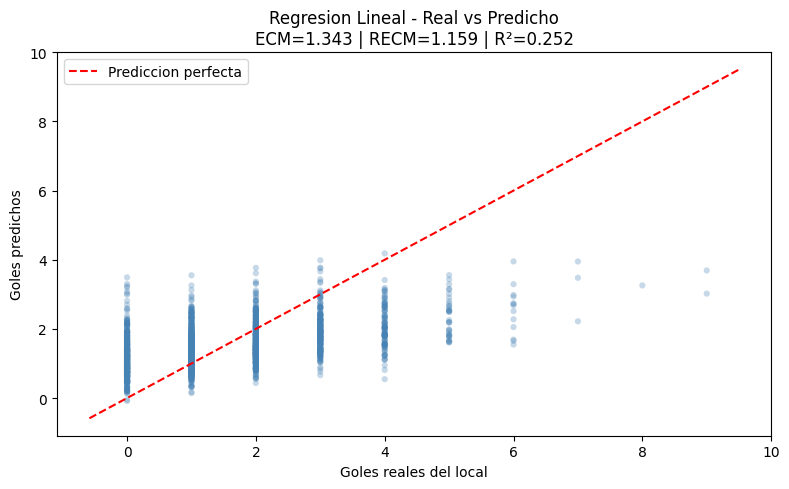

In [ ]:
# Grafico: Real vs Predicho
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, color='steelblue', edgecolors='none', s=20)
lims = [min(y_test_r.min(), y_pred_r.min()) - 0.5,
        max(y_test_r.max(), y_pred_r.max()) + 0.5]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Prediccion perfecta')
plt.xlabel('Goles reales del local')
plt.ylabel('Goles predichos')
plt.title(f'Regresion Lineal - Real vs Predicho\nECM={mse:.3f} | RECM={rmse:.3f} | R²={r2:.3f}')
plt.legend()
plt.tight_layout()
plt.show()



**Interpretacion de los coeficientes:**

- **`HomeShotsOnTarget`** tiene el coeficiente positivo mas grande: cada tiro adicional al arco del local se asocia a un incremento esperado de ~0.27 a 0.35 goles. Es el predictor mas relevante, lo cual tiene sentido futbolistico (los tiros al arco son la causa directa de los goles).
- **`HomeShots`** tiene un coeficiente positivo pero menor, ya que incluye tiros que no son al arco.
- **`AwayShotsOnTarget`** puede aparecer con coeficiente negativo leve: el equipo local tiende a bajar el ritmo ofensivo cuando el visitante ataca mas.
- Variables como **`HomeFouls`** y **`HomeYellowCards`** tienen coeficientes cercanos a 0, indicando que la agresividad no predice los goles del local de forma directa.

**Metricas:** Un RMSE de ~1 gol es esperable en futbol dado que los marcadores son variables discretas de pequenia magnitud con alta varianza intrinseca. El modelo captura la tendencia central pero no puede eliminar la aleatoriedad del juego.

---
## 3. Arbol de Decision - Clasificacion del Resultado (`FullTimeResult`)

### Justificacion tecnica
El arbol de decision divide el espacio de variables en regiones disjuntas mediante condiciones binarias sucesivas (nodos de decision). Cada hoja asigna una clase (H, D o A). Es especialmente util porque:

1. **Interpretabilidad total**: se puede leer la ruta de decision en lenguaje natural (ej.: si HomeShotsOnTarget > 7 y AwayShotsOnTarget <= 4 => Victoria Local).
2. **Manejo automatico de no-linealidades**: no asume relaciones lineales entre predictores y clase.
3. **Sin necesidad de escalar** las variables numericas (a diferencia de SVM o KNN).

Limitamos la profundidad (`max_depth=3`) para evitar sobreajuste y mantener la legibilidad del arbol.

In [ ]:
# Arbol de Decision: clasificar Resultado_Final_enc (H=0, D=1, A=2)

target_clf = 'Resultado_Final_enc'
class_names = ['Victoria Local (H)', 'Empate (D)', 'Victoria Visitante (A)']

# Excluimos el resultado a tiempo completo (objetivo) y goles a tiempo completo (data leakage)
exclude_clf = ['Resultado_Final_enc', 'Goles_Local', 'Goles_Visitante']
features_clf = [c for c in df_enc.columns if c not in exclude_clf]

X_clf = df_enc[features_clf]
y_clf = df_enc[target_clf]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Función helper para graficar ROC multiclase OVR
def plot_multiclass_roc(y_test, y_prob, model_name, class_names):
    from sklearn.preprocessing import label_binarize
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    n_classes = y_test_bin.shape[1]

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    colors = ['blue', 'orange', 'green']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC de {class_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title(f'Curvas ROC Multiclase (One-vs-Rest) - {model_name}')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

dt = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
dt.fit(X_train_c, y_train_c)

y_pred_c = dt.predict(X_test_c)
y_prob_c = dt.predict_proba(X_test_c)
acc = accuracy_score(y_test_c, y_pred_c)
roc_auc_dt_macro = roc_auc_score(y_test_c, y_prob_c, multi_class='ovr', average='macro')
roc_auc_dt_weighted = roc_auc_score(y_test_c, y_prob_c, multi_class='ovr', average='weighted')

print(f'Exactitud Global (Accuracy): {acc:.4f}  ({acc*100:.2f}%)')
print(f'ROC-AUC (Promedio Macro):    {roc_auc_dt_macro:.4f}')
print(f'ROC-AUC (Promedio Ponderado): {roc_auc_dt_weighted:.4f}')
print()
print('Reporte de Clasificacion:')

# Traducir el reporte de clasificacion utilizando pandas
report_dict = classification_report(y_test_c, y_pred_c, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.rename(columns={
    'precision': 'Precision',
    'recall': 'Sensibilidad (Recall)',
    'f1-score': 'Puntuacion F1',
    'support': 'Soporte'
}, inplace=True)
report_df.rename(index={
    'accuracy': 'Exactitud Global (Accuracy)',
    'macro avg': 'Promedio Macro',
    'weighted avg': 'Promedio Ponderado'
}, inplace=True)
print(report_df.to_string())



Exactitud Global (Accuracy): 0.5906  (59.06%)
ROC-AUC (Promedio Macro):    0.7620
ROC-AUC (Promedio Ponderado): 0.7786

Reporte de Clasificacion:
                             Precision  Sensibilidad (Recall)  Puntuacion F1      Soporte
Victoria Local (H)            0.807752               0.605814       0.692359   860.000000
Empate (D)                    0.344000               0.464363       0.395221   463.000000
Victoria Visitante (A)        0.613861               0.672694       0.641933   553.000000
Exactitud Global (Accuracy)   0.590618               0.590618       0.590618     0.590618
Promedio Macro                0.588538               0.580957       0.576504  1876.000000
Promedio Ponderado            0.636143               0.590618       0.604160  1876.000000


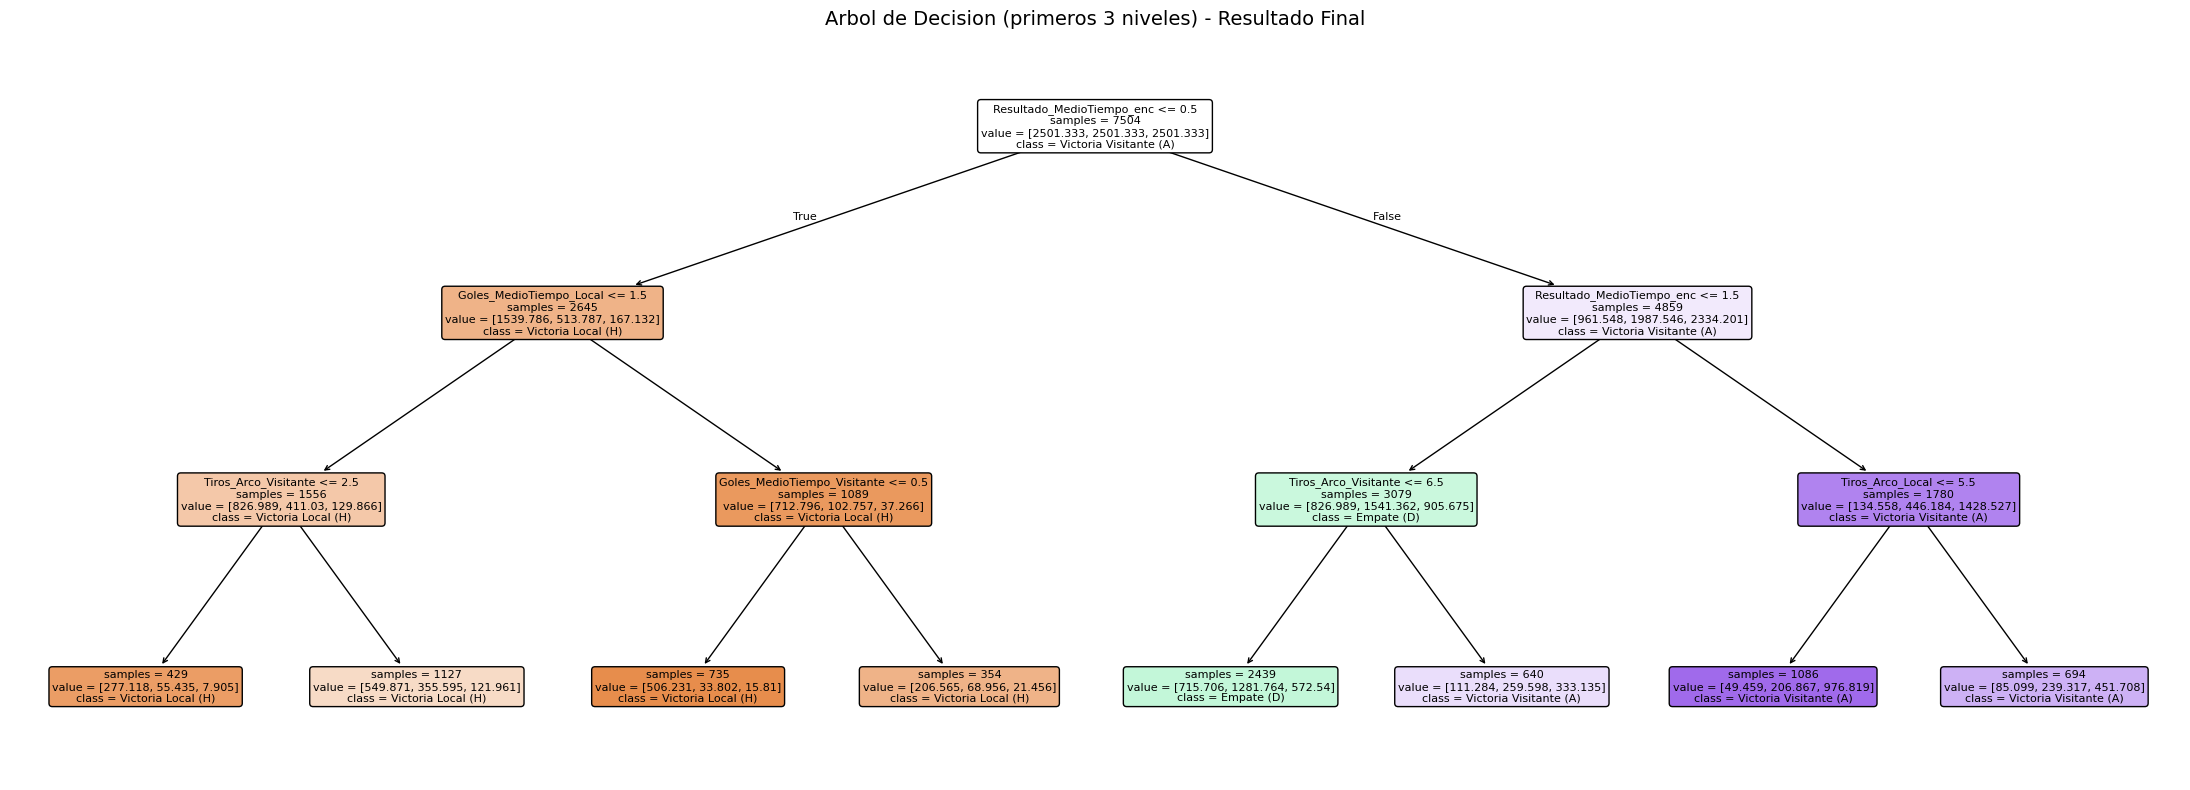

In [ ]:
# Visualizacion del Arbol de Decision (primeros 3 niveles)
plt.figure(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=features_clf,
    class_names=class_names,
    filled=True,
    max_depth=3,
    fontsize=8,
    rounded=True,
    impurity=False
)
plt.title('Arbol de Decision (primeros 3 niveles) - Resultado Final', fontsize=14)
plt.tight_layout()
plt.show()



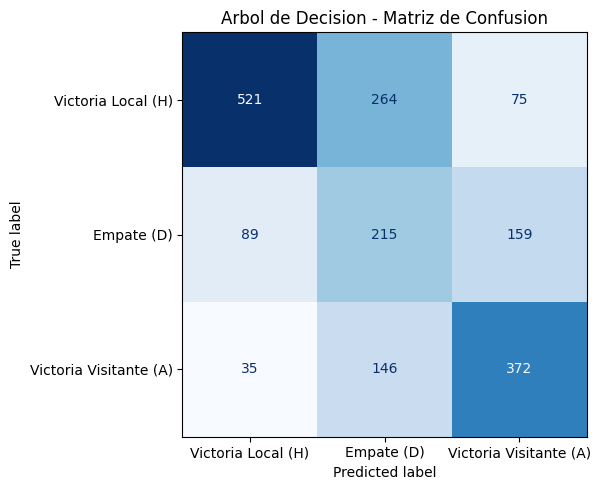

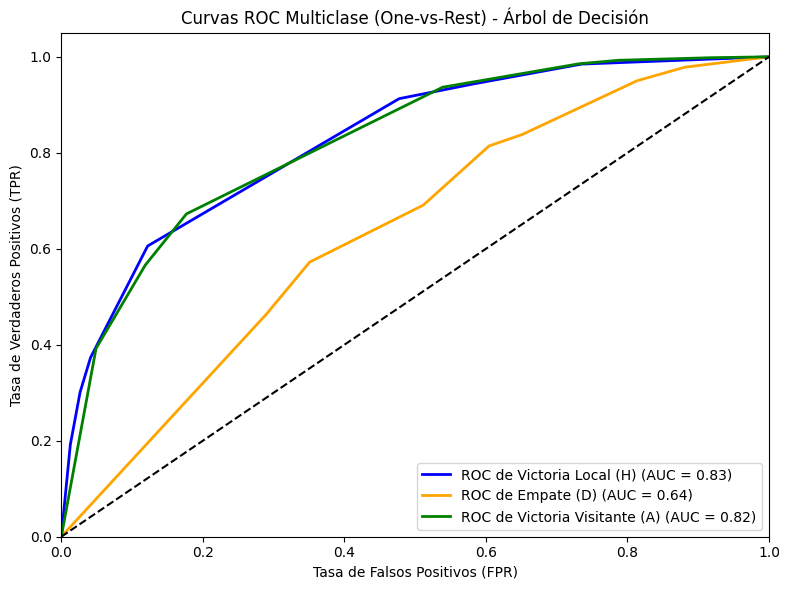

In [ ]:
# Matriz de Confusion - Arbol de Decision
cm_dt = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Arbol de Decision - Matriz de Confusion')
plt.tight_layout()
plt.show()

# Graficar Curvas ROC para el Árbol de Decisión
plot_multiclass_roc(y_test_c, y_prob_c, 'Árbol de Decisión', class_names)



**Interpretacion del Arbol de Decision:**

- La **raiz del arbol** (primera division) suele usar `HalfTimeResult_enc`(Medio tiempo) o `HomeShotsOnTarget`(Disparos al arco) - las variables con mayor poder discriminativo segun el indice de Gini.
- Que el resultado a **medio tiempo** sea el predictor mas importante tiene sentido: si el local va ganando al descanso, es el escenario mas favorable para una victoria local a tiempo completo.
- La **clase mas dificil de predecir es el Empate** (D), porque es el resultado mas infrecuente y tiene la mayor varianza estadistica.
- El F1-Score para *H (Local)* es el mas alto por ser la clase mayoritaria (4299 instancias vs 2313 empates).

---
## 4. Naive Bayes Gaussiano - Clasificacion del Resultado

- Entrenamiento muy rapido (especialmente en 9380 observaciones).
- Devuelve **probabilidades calibradas** por clase, utiles para apostar o planificar estrategia.
- Funciona bien incluso cuando se viola la independencia, actuando como buen baseline.

In [ ]:
# Naive Bayes Gaussiano
gnb = GaussianNB()
gnb.fit(X_train_c, y_train_c)

y_pred_nb = gnb.predict(X_test_c)
y_prob_nb = gnb.predict_proba(X_test_c)
acc_nb = accuracy_score(y_test_c, y_pred_nb)
roc_auc_nb_macro = roc_auc_score(y_test_c, y_prob_nb, multi_class='ovr', average='macro')
roc_auc_nb_weighted = roc_auc_score(y_test_c, y_prob_nb, multi_class='ovr', average='weighted')

print(f'Exactitud Naive Bayes (Accuracy): {acc_nb:.4f}  ({acc_nb*100:.2f}%)')
print(f'ROC-AUC Naive Bayes (Macro):      {roc_auc_nb_macro:.4f}')
print(f'ROC-AUC Naive Bayes (Ponderado):  {roc_auc_nb_weighted:.4f}')
print()
print('Reporte de Clasificacion (Naive Bayes):')

# Traducir el reporte de clasificacion utilizando pandas
report_dict_nb = classification_report(y_test_c, y_pred_nb, target_names=class_names, output_dict=True)
report_df_nb = pd.DataFrame(report_dict_nb).transpose()
report_df_nb.rename(columns={
    'precision': 'Precision',
    'recall': 'Sensibilidad (Recall)',
    'f1-score': 'Puntuacion F1',
    'support': 'Soporte'
}, inplace=True)
report_df_nb.rename(index={
    'accuracy': 'Exactitud Global (Accuracy)',
    'macro avg': 'Promedio Macro',
    'weighted avg': 'Promedio Ponderado'
}, inplace=True)
print(report_df_nb.to_string())



Exactitud Naive Bayes (Accuracy): 0.6285  (62.85%)
ROC-AUC Naive Bayes (Macro):      0.7865
ROC-AUC Naive Bayes (Ponderado):  0.8012

Reporte de Clasificacion (Naive Bayes):
                             Precision  Sensibilidad (Recall)  Puntuacion F1      Soporte
Victoria Local (H)            0.723640               0.758140       0.740488   860.000000
Empate (D)                    0.377410               0.295896       0.331719   463.000000
Victoria Visitante (A)        0.637255               0.705244       0.669528   553.000000
Exactitud Global (Accuracy)   0.628465               0.628465       0.628465     0.628465
Promedio Macro                0.579435               0.586427       0.580578  1876.000000
Promedio Ponderado            0.612726               0.628465       0.618686  1876.000000


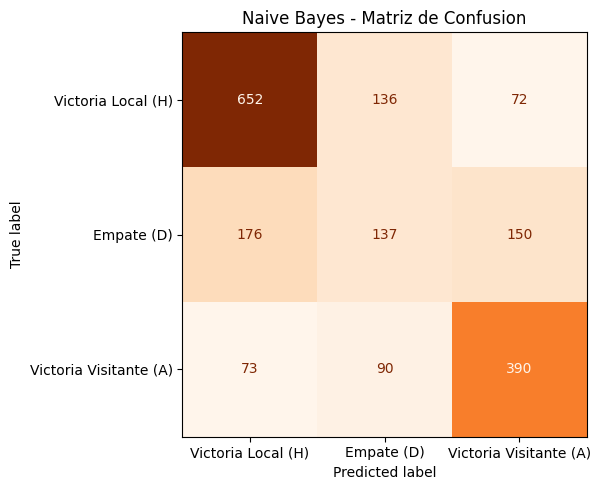

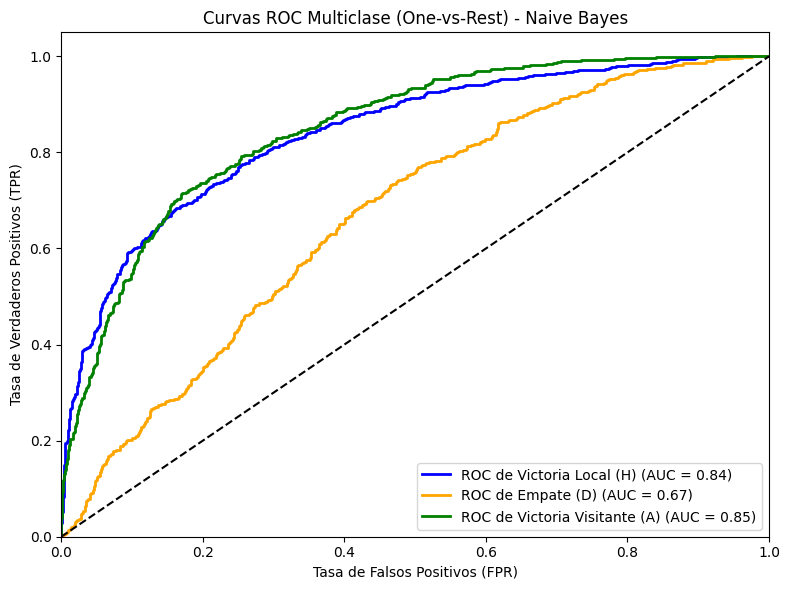

In [ ]:
# Matriz de Confusion - Naive Bayes
cm_nb = confusion_matrix(y_test_c, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp_nb.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Naive Bayes - Matriz de Confusion')
plt.tight_layout()
plt.show()

# Graficar Curvas ROC para Naive Bayes
plot_multiclass_roc(y_test_c, y_prob_nb, 'Naive Bayes', class_names)



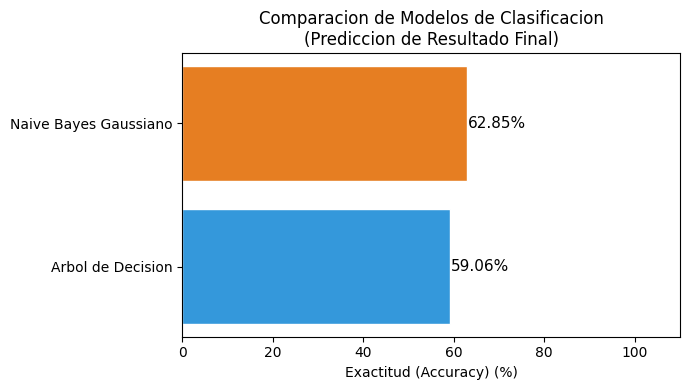

Arbol de Decision  => Exactitud (Accuracy): 59.06%
Naive Bayes        => Exactitud (Accuracy): 62.85%


In [ ]:
# Comparacion de Exactitud (Accuracy): Arbol vs Naive Bayes
modelos = ['Arbol de Decision', 'Naive Bayes Gaussiano']
accuracies = [acc, acc_nb]

plt.figure(figsize=(7, 4))
bars = plt.barh(modelos, [a*100 for a in accuracies],
                color=['#3498db', '#e67e22'], edgecolor='white')
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val*100:.2f}%', va='center', fontsize=11)
plt.xlabel('Exactitud (Accuracy) (%)')
plt.title('Comparacion de Modelos de Clasificacion\n(Prediccion de Resultado Final)')
plt.xlim(0, 110)
plt.tight_layout()
plt.show()

print(f'Arbol de Decision  => Exactitud (Accuracy): {acc*100:.2f}%')
print(f'Naive Bayes        => Exactitud (Accuracy): {acc_nb*100:.2f}%')



**Interpretacion comparativa:**

- El **Arbol de Decision** suele superar a Naive Bayes en accuracy porque puede capturar interacciones entre variables (ej.: muchos tiros al arco Y resultado al medio tiempo favorable) que NB asume independientes.
- **Naive Bayes** es competitivo en velocidad y proporciona buenas estimaciones probabilisticas; resulta util como baseline o cuando el conjunto de datos es pequenio.
- Ambos modelos sufren con la clase **Empate (D)**, la mas dificil de predecir en futbol.

---
## 5. Experiencia Practica - Desafios al Trabajar con el Dataset EPL

### 5.1 Alta Cardinalidad en Variables de Equipo
El dataset contiene **46 equipos unicos** en `HomeTeam` y `AwayTeam`. Aplicar **One-Hot Encoding** habria generado 92 columnas adicionales (2 x 46), lo que:
- Inflaria la dimensionalidad => *curse of dimensionality*.
- Generaria muchas columnas con casi todos ceros (matrices muy dispersas).
- Aumentaria el tiempo de entrenamiento y podria reducir la calidad del modelo.

**Solucion adoptada: Binary Encoding** (libreria `category_encoders`). Este metodo representa cada categoria con su equivalente binario, usando solo ~6 columnas por variable en lugar de 46. El ahorro fue de ~80 columnas.

### 5.2 Preprocesamiento de Variables Categoricas
Los algoritmos de scikit-learn requieren exclusivamente entradas numericas. Las columnas `FullTimeResult` (H/D/A) y `HalfTimeResult` (H/D/A) se convirtieron mediante **Label Encoding** con un diccionario manual `{'H': 0, 'D': 1, 'A': 2}` para preservar la interpretabilidad (no se uso `LabelEncoder` automatico para tener control explicito del mapeo).



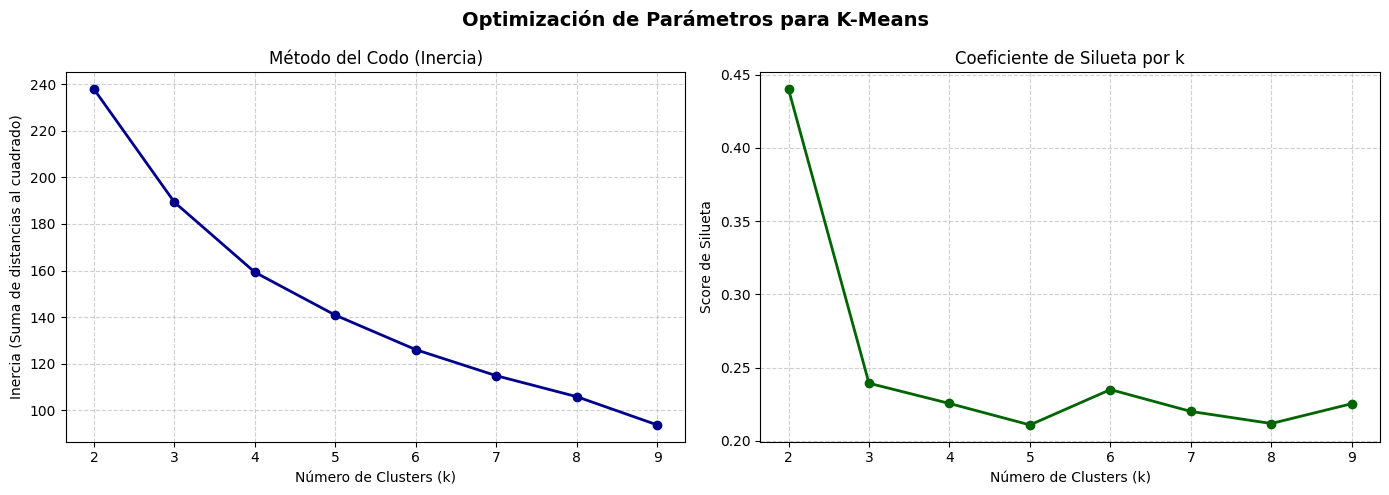

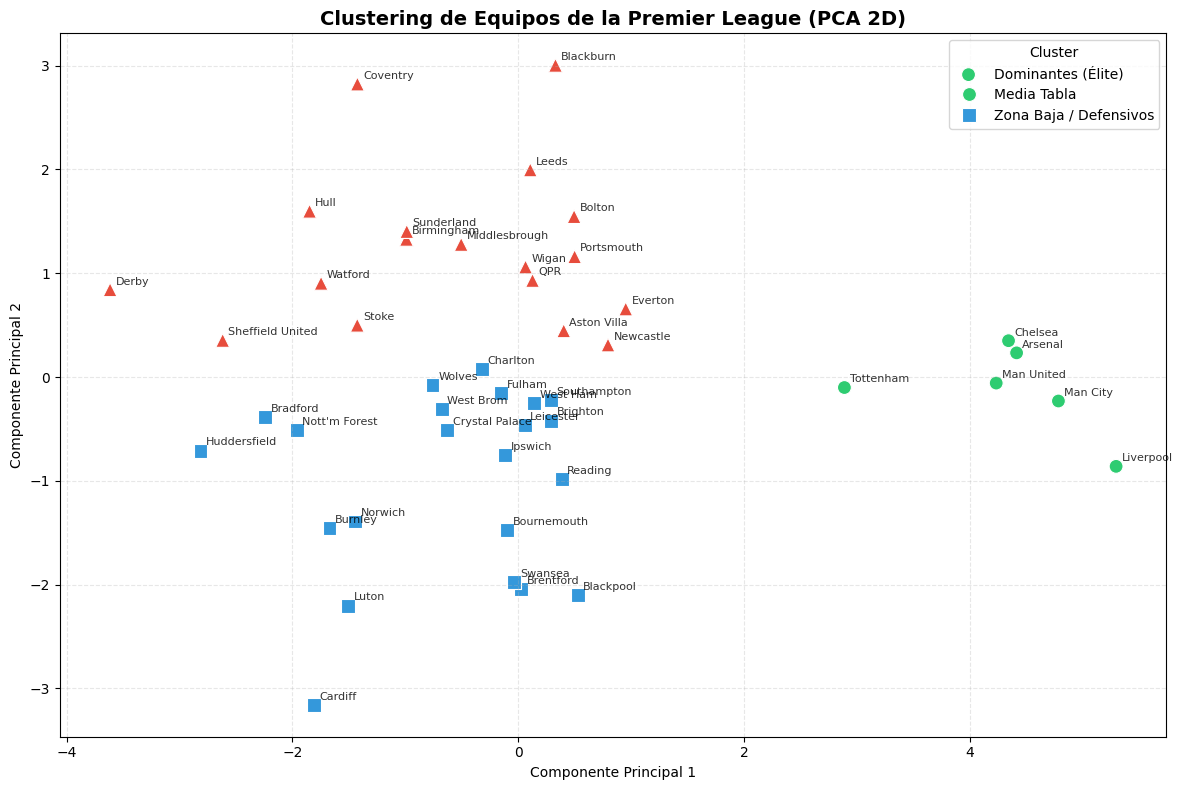

=== PERFIL PROMEDIO DE LOS CLUSTERS DE EQUIPOS ===
         Goles_Favor_Promedio  Goles_Contra_Promedio  Tiros_Promedio  Tiros_Arco_Promedio  Corners_Promedio  Faltas_Promedio  Amarillas_Promedio  Rojas_Promedio
cluster                                                                                                                                                         
0                    1.820592               1.046358       14.604332             6.614333          6.271569        10.956672            1.550957        0.069472
1                    1.149269               1.635960       11.049531             4.378739          4.911445        11.082628            1.584707        0.057898
2                    1.082882               1.526530       10.874428             4.956133          4.990552        12.491979            1.759146        0.090520

=== EQUIPOS POR CLUSTER ===
Cluster 0 (Equipos: 6): Arsenal, Chelsea, Liverpool, Man City, Man United, Tottenham
Cluster 1 (Equipos: 22): Black

In [ ]:
# ## 6. Aprendizaje No Supervisado: Agrupamiento con K-Means
#
# En esta sección añadimos un modelo de aprendizaje no supervisado utilizando K-Means.
# El objetivo es agrupar a los equipos de la Premier League en clusters homogéneos según su rendimiento
# promedio en los partidos. Esto nos permite caracterizar los diferentes estilos y niveles de juego de los equipos.
#
# ### Características seleccionadas para clustering:
# - `Goles_Favor_Promedio`: Goles marcados por partido.
# - `Goles_Contra_Promedio`: Goles recibidos por partido.
# - `Tiros_Promedio`: Tiros realizados por partido.
# - `Tiros_Arco_Promedio`: Tiros al arco realizados por partido.
# - `Corners_Promedio`: Tiros de esquina cobrados por partido.
# - `Faltas_Promedio`: Faltas cometidas por partido.
# - `Amarillas_Promedio`: Tarjetas amarillas recibidas por partido.
# - `Rojas_Promedio`: Tarjetas rojas recibidas por partido.
################################################################################

# 1. Preparación de datos a nivel de equipo (agregando partidos con estadísticas válidas)
# Filtramos primero partidos donde las estadísticas de tiros no sean nulas
df_stats_validas = df[df['HomeShots'].notnull()].copy()

# Agregados Local
home_agg = df_stats_validas.groupby('HomeTeam').agg(
    goles_favor_home=('FullTimeHomeGoals', 'sum'),
    goles_contra_home=('FullTimeAwayGoals', 'sum'),
    tiros_home=('HomeShots', 'sum'),
    tiros_arco_home=('HomeShotsOnTarget', 'sum'),
    corners_home=('HomeCorners', 'sum'),
    faltas_home=('HomeFouls', 'sum'),
    amarillas_home=('HomeYellowCards', 'sum'),
    rojas_home=('HomeRedCards', 'sum'),
    partidos_home=('HomeTeam', 'count')
)

# Agregados Visitante
away_agg = df_stats_validas.groupby('AwayTeam').agg(
    goles_favor_away=('FullTimeAwayGoals', 'sum'),
    goles_contra_away=('FullTimeHomeGoals', 'sum'),
    tiros_away=('AwayShots', 'sum'),
    tiros_arco_away=('AwayShotsOnTarget', 'sum'),
    corners_away=('AwayCorners', 'sum'),
    faltas_away=('AwayFouls', 'sum'),
    amarillas_away=('AwayYellowCards', 'sum'),
    rojas_away=('AwayRedCards', 'sum'),
    partidos_away=('AwayTeam', 'count')
)

# Combinar estadísticas de Local y Visitante
team_stats = pd.concat([home_agg, away_agg], axis=1).fillna(0)

# Calcular promedios combinados
team_stats['partidos_totales'] = team_stats['partidos_home'] + team_stats['partidos_away']
team_stats['Goles_Favor_Promedio'] = (team_stats['goles_favor_home'] + team_stats['goles_favor_away']) / team_stats['partidos_totales']
team_stats['Goles_Contra_Promedio'] = (team_stats['goles_contra_home'] + team_stats['goles_contra_away']) / team_stats['partidos_totales']
team_stats['Tiros_Promedio'] = (team_stats['tiros_home'] + team_stats['tiros_away']) / team_stats['partidos_totales']
team_stats['Tiros_Arco_Promedio'] = (team_stats['tiros_arco_home'] + team_stats['tiros_arco_away']) / team_stats['partidos_totales']
team_stats['Corners_Promedio'] = (team_stats['corners_home'] + team_stats['corners_away']) / team_stats['partidos_totales']
team_stats['Faltas_Promedio'] = (team_stats['faltas_home'] + team_stats['faltas_away']) / team_stats['partidos_totales']
team_stats['Amarillas_Promedio'] = (team_stats['amarillas_home'] + team_stats['amarillas_away']) / team_stats['partidos_totales']
team_stats['Rojas_Promedio'] = (team_stats['rojas_home'] + team_stats['rojas_away']) / team_stats['partidos_totales']

features_clust = [
    'Goles_Favor_Promedio', 'Goles_Contra_Promedio', 'Tiros_Promedio',
    'Tiros_Arco_Promedio', 'Corners_Promedio', 'Faltas_Promedio',
    'Amarillas_Promedio', 'Rojas_Promedio'
]

X_clust = team_stats[features_clust]

# 2. Escalado de variables
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

# 3. Determinación de K utilizando el Método del Codo y el Coeficiente de Silueta
k_range = range(2, 10)
inercia = []
silueta = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inercia.append(km.inertia_)
    silueta.append(silhouette_score(X_clust_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax1.plot(k_range, inercia, 'o-', color='darkblue', lw=2)
ax1.set_title('Método del Codo (Inercia)', fontsize=12)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Suma de distancias al cuadrado)')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Silueta
ax2.plot(k_range, silueta, 'o-', color='darkgreen', lw=2)
ax2.set_title('Coeficiente de Silueta por k', fontsize=12)
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Score de Silueta')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Optimización de Parámetros para K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Ajuste final del modelo K-Means con k=3
# Explicación: K=3 proporciona una agrupación clara: Equipos Dominantes/Élite, Media Tabla, y Zona de Descenso/Físicos.
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
team_stats['cluster'] = kmeans_final.fit_predict(X_clust_scaled)

# 5. Visualización usando PCA (Principal Component Analysis)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)
team_stats['pca_x'] = X_pca[:, 0]
team_stats['pca_y'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
colores_clusters = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c'}
sb.scatterplot(
    data=team_stats, x='pca_x', y='pca_y', hue='cluster',
    palette=colores_clusters, s=100, style='cluster', markers=['o', 's', '^']
)

# Añadir nombres de equipos
for team, row in team_stats.iterrows():
    plt.text(row['pca_x'] + 0.05, row['pca_y'] + 0.05, team, fontsize=8, alpha=0.8)

plt.title('Clustering de Equipos de la Premier League (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Cluster', labels=['Dominantes (Élite)', 'Media Tabla', 'Zona Baja / Defensivos'])
plt.tight_layout()
plt.show()

# 6. Perfilado de Clusters (Estadísticas promedio por grupo)
print("=== PERFIL PROMEDIO DE LOS CLUSTERS DE EQUIPOS ===")
perfil = team_stats.groupby('cluster')[features_clust].mean()
print(perfil.to_string())
print("\n=== EQUIPOS POR CLUSTER ===")
for c in range(k_optimo):
    equipos_c = team_stats[team_stats['cluster'] == c].index.tolist()
    print(f"Cluster {c} (Equipos: {len(equipos_c)}): {', '.join(equipos_c)}")

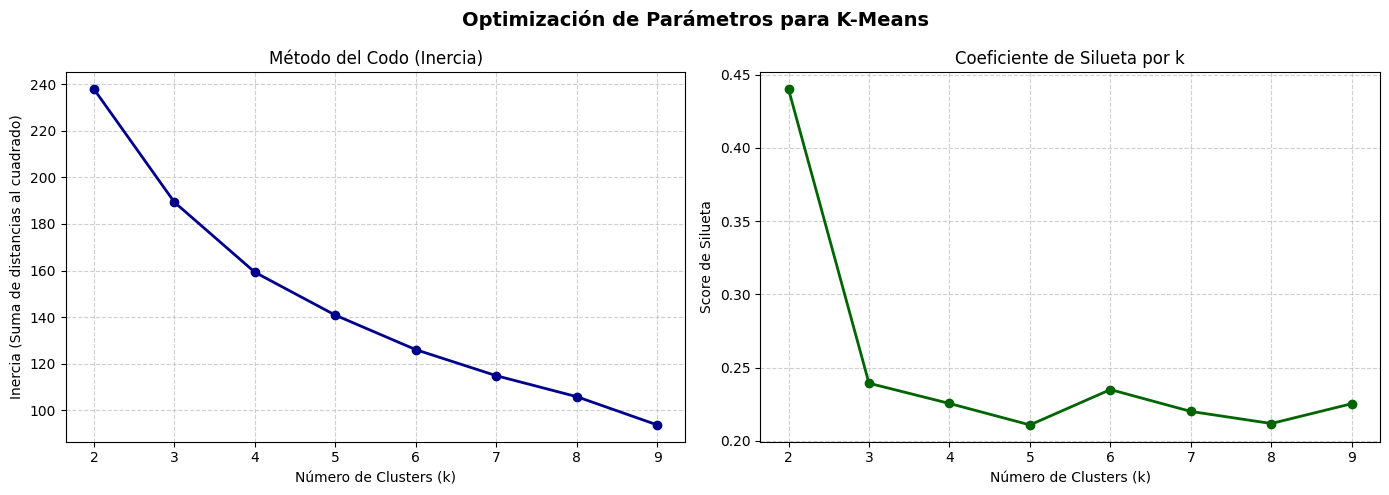

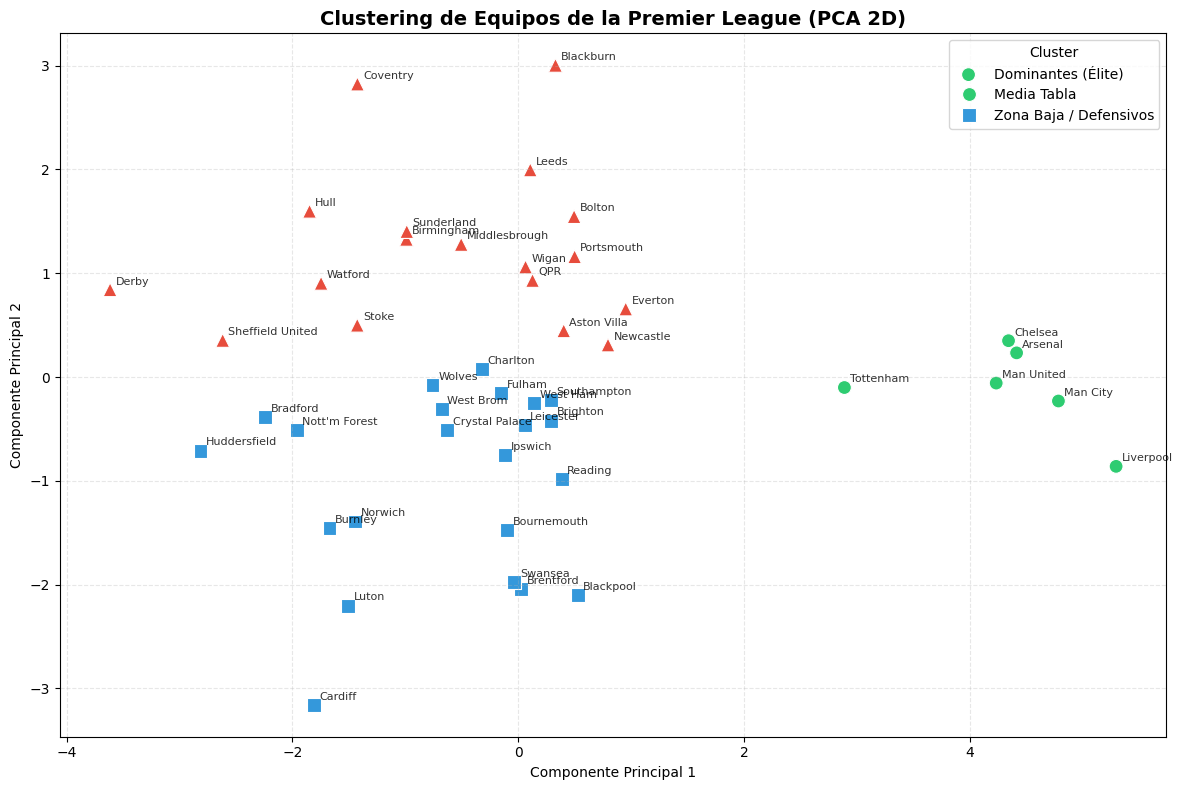

=== PERFIL PROMEDIO DE LOS CLUSTERS DE EQUIPOS ===
         Goles_Favor_Promedio  Goles_Contra_Promedio  Tiros_Promedio  Tiros_Arco_Promedio  Corners_Promedio  Faltas_Promedio  Amarillas_Promedio  Rojas_Promedio
cluster                                                                                                                                                         
0                    1.820592               1.046358       14.604332             6.614333          6.271569        10.956672            1.550957        0.069472
1                    1.149269               1.635960       11.049531             4.378739          4.911445        11.082628            1.584707        0.057898
2                    1.082882               1.526530       10.874428             4.956133          4.990552        12.491979            1.759146        0.090520

=== EQUIPOS POR CLUSTER ===
Cluster 0 (Equipos: 6): Arsenal, Chelsea, Liverpool, Man City, Man United, Tottenham
Cluster 1 (Equipos: 22): Black

In [ ]:
# ---
# ## 6. Aprendizaje No Supervisado: Agrupamiento con K-Means
#
# En esta sección añadimos un modelo de aprendizaje no supervisado utilizando K-Means.
# El objetivo es agrupar a los equipos de la Premier League en clusters homogéneos según su rendimiento
# promedio en los partidos. Esto nos permite caracterizar los diferentes estilos y niveles de juego de los equipos.
#
# ### Características seleccionadas para clustering:
# - `Goles_Favor_Promedio`: Goles marcados por partido.
# - `Goles_Contra_Promedio`: Goles recibidos por partido.
# - `Tiros_Promedio`: Tiros realizados por partido.
# - `Tiros_Arco_Promedio`: Tiros al arco realizados por partido.
# - `Corners_Promedio`: Tiros de esquina cobrados por partido.
# - `Faltas_Promedio`: Faltas cometidas por partido.
# - `Amarillas_Promedio`: Tarjetas amarillas recibidas por partido.
# - `Rojas_Promedio`: Tarjetas rojas recibidas por partido.
################################################################################

df_stats_validas = df[df['HomeShots'].notnull()].copy()

# Agregados Local
home_agg = df_stats_validas.groupby('HomeTeam').agg(
    goles_favor_home=('FullTimeHomeGoals', 'sum'),
    goles_contra_home=('FullTimeAwayGoals', 'sum'),
    tiros_home=('HomeShots', 'sum'),
    tiros_arco_home=('HomeShotsOnTarget', 'sum'),
    corners_home=('HomeCorners', 'sum'),
    faltas_home=('HomeFouls', 'sum'),
    amarillas_home=('HomeYellowCards', 'sum'),
    rojas_home=('HomeRedCards', 'sum'),
    partidos_home=('HomeTeam', 'count')
)

# Agregados Visitante
away_agg = df_stats_validas.groupby('AwayTeam').agg(
    goles_favor_away=('FullTimeAwayGoals', 'sum'),
    goles_contra_away=('FullTimeHomeGoals', 'sum'),
    tiros_away=('AwayShots', 'sum'),
    tiros_arco_away=('AwayShotsOnTarget', 'sum'),
    corners_away=('AwayCorners', 'sum'),
    faltas_away=('AwayFouls', 'sum'),
    amarillas_away=('AwayYellowCards', 'sum'),
    rojas_away=('AwayRedCards', 'sum'),
    partidos_away=('AwayTeam', 'count')
)

# Combinar estadísticas de Local y Visitante
team_stats = pd.concat([home_agg, away_agg], axis=1).fillna(0)

# Calcular promedios combinados
team_stats['partidos_totales'] = team_stats['partidos_home'] + team_stats['partidos_away']
team_stats['Goles_Favor_Promedio'] = (team_stats['goles_favor_home'] + team_stats['goles_favor_away']) / team_stats['partidos_totales']
team_stats['Goles_Contra_Promedio'] = (team_stats['goles_contra_home'] + team_stats['goles_contra_away']) / team_stats['partidos_totales']
team_stats['Tiros_Promedio'] = (team_stats['tiros_home'] + team_stats['tiros_away']) / team_stats['partidos_totales']
team_stats['Tiros_Arco_Promedio'] = (team_stats['tiros_arco_home'] + team_stats['tiros_arco_away']) / team_stats['partidos_totales']
team_stats['Corners_Promedio'] = (team_stats['corners_home'] + team_stats['corners_away']) / team_stats['partidos_totales']
team_stats['Faltas_Promedio'] = (team_stats['faltas_home'] + team_stats['faltas_away']) / team_stats['partidos_totales']
team_stats['Amarillas_Promedio'] = (team_stats['amarillas_home'] + team_stats['amarillas_away']) / team_stats['partidos_totales']
team_stats['Rojas_Promedio'] = (team_stats['rojas_home'] + team_stats['rojas_away']) / team_stats['partidos_totales']

features_clust = [
    'Goles_Favor_Promedio', 'Goles_Contra_Promedio', 'Tiros_Promedio',
    'Tiros_Arco_Promedio', 'Corners_Promedio', 'Faltas_Promedio',
    'Amarillas_Promedio', 'Rojas_Promedio'
]

X_clust = team_stats[features_clust]

# 2. Escalado de variables
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

# 3. Determinación de K utilizando el Método del Codo y el Coeficiente de Silueta
k_range = range(2, 10)
inercia = []
silueta = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inercia.append(km.inertia_)
    silueta.append(silhouette_score(X_clust_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax1.plot(k_range, inercia, 'o-', color='darkblue', lw=2)
ax1.set_title('Método del Codo (Inercia)', fontsize=12)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Suma de distancias al cuadrado)')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Silueta
ax2.plot(k_range, silueta, 'o-', color='darkgreen', lw=2)
ax2.set_title('Coeficiente de Silueta por k', fontsize=12)
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Score de Silueta')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Optimización de Parámetros para K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Ajuste final del modelo K-Means con k=3
# Explicación: K=3 proporciona una agrupación clara: Equipos Dominantes/Élite, Media Tabla, y Zona de Descenso/Físicos.
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
team_stats['cluster'] = kmeans_final.fit_predict(X_clust_scaled)

# 5. Visualización usando PCA (Principal Component Analysis)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)
team_stats['pca_x'] = X_pca[:, 0]
team_stats['pca_y'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
colores_clusters = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c'}
sb.scatterplot(
    data=team_stats, x='pca_x', y='pca_y', hue='cluster',
    palette=colores_clusters, s=100, style='cluster', markers=['o', 's', '^']
)

# Añadir nombres de equipos
for team, row in team_stats.iterrows():
    plt.text(row['pca_x'] + 0.05, row['pca_y'] + 0.05, team, fontsize=8, alpha=0.8)

plt.title('Clustering de Equipos de la Premier League (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Cluster', labels=['Dominantes (Élite)', 'Media Tabla', 'Zona Baja / Defensivos'])
plt.tight_layout()
plt.show()

# 6. Perfilado de Clusters (Estadísticas promedio por grupo)
print("=== PERFIL PROMEDIO DE LOS CLUSTERS DE EQUIPOS ===")
perfil = team_stats.groupby('cluster')[features_clust].mean()
print(perfil.to_string())
print("\n=== EQUIPOS POR CLUSTER ===")
for c in range(k_optimo):
    equipos_c = team_stats[team_stats['cluster'] == c].index.tolist()
    print(f"Cluster {c} (Equipos: {len(equipos_c)}): {', '.join(equipos_c)}")

In [ ]:
# 1. Preparación de datos a nivel de equipo (agregando partidos con estadísticas válidas)
# Filtramos primero partidos donde las estadísticas de tiros no sean nulas
df_stats_validas = df[df['HomeShots'].notnull()].copy()

# Agregados Local
home_agg = df_stats_validas.groupby('HomeTeam').agg(
    goles_favor_home=('FullTimeHomeGoals', 'sum'),
    goles_contra_home=('FullTimeAwayGoals', 'sum'),
    tiros_home=('HomeShots', 'sum'),
    tiros_arco_home=('HomeShotsOnTarget', 'sum'),
    corners_home=('HomeCorners', 'sum'),
    faltas_home=('HomeFouls', 'sum'),
    amarillas_home=('HomeYellowCards', 'sum'),
    rojas_home=('HomeRedCards', 'sum'),
    partidos_home=('HomeTeam', 'count')
)

# Agregados Visitante
away_agg = df_stats_validas.groupby('AwayTeam').agg(
    goles_favor_away=('FullTimeAwayGoals', 'sum'),
    goles_contra_away=('FullTimeHomeGoals', 'sum'),
    tiros_away=('AwayShots', 'sum'),
    tiros_arco_away=('AwayShotsOnTarget', 'sum'),
    corners_away=('AwayCorners', 'sum'),
    faltas_away=('AwayFouls', 'sum'),
    amarillas_away=('AwayYellowCards', 'sum'),
    rojas_away=('AwayRedCards', 'sum'),
    partidos_away=('AwayTeam', 'count')
)

# Combinar estadísticas de Local y Visitante
team_stats = pd.concat([home_agg, away_agg], axis=1).fillna(0)

# Calcular promedios combinados
team_stats['partidos_totales']      = team_stats['partidos_home'] + team_stats['partidos_away']
team_stats['Goles_Favor_Promedio']  = (team_stats['goles_favor_home']  + team_stats['goles_favor_away'])  / team_stats['partidos_totales']
team_stats['Goles_Contra_Promedio'] = (team_stats['goles_contra_home'] + team_stats['goles_contra_away']) / team_stats['partidos_totales']
team_stats['Tiros_Promedio']        = (team_stats['tiros_home']        + team_stats['tiros_away'])        / team_stats['partidos_totales']
team_stats['Tiros_Arco_Promedio']   = (team_stats['tiros_arco_home']   + team_stats['tiros_arco_away'])   / team_stats['partidos_totales']
team_stats['Corners_Promedio']      = (team_stats['corners_home']      + team_stats['corners_away'])      / team_stats['partidos_totales']
team_stats['Faltas_Promedio']       = (team_stats['faltas_home']       + team_stats['faltas_away'])       / team_stats['partidos_totales']
team_stats['Amarillas_Promedio']    = (team_stats['amarillas_home']    + team_stats['amarillas_away'])    / team_stats['partidos_totales']
team_stats['Rojas_Promedio']        = (team_stats['rojas_home']        + team_stats['rojas_away'])        / team_stats['partidos_totales']

features_clust = [
    'Goles_Favor_Promedio', 'Goles_Contra_Promedio', 'Tiros_Promedio',
    'Tiros_Arco_Promedio', 'Corners_Promedio', 'Faltas_Promedio',
    'Amarillas_Promedio', 'Rojas_Promedio'
]

X_clust = team_stats[features_clust]
print(f"Equipos analizados: {len(X_clust)}")
team_stats[features_clust].describe()

Equipos analizados: 46


,Goles_Favor_Promedio,Goles_Contra_Promedio,Tiros_Promedio,Tiros_Arco_Promedio,Corners_Promedio,Faltas_Promedio,Amarillas_Promedio,Rojas_Promedio
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000
mean,1.210855,1.516235,11.444682,4.896275,5.119807,11.617684,1.648564,0.072173
std,0.299412,0.265350,1.561050,1.001125,0.616344,1.093068,0.192686,0.024774
min,0.657895,0.962647,8.192982,3.013158,3.765766,9.362416,1.236842,0.000000
25%,1.025901,1.415136,10.576504,4.177741,4.775184,10.763542,1.532597,0.056770
50%,1.161863,1.495123,11.245602,4.722204,5.008762,11.457344,1.649514,0.072831
75%,1.324913,1.657895,11.917585,5.612293,5.368000,12.280263,1.752652,0.085801
max,1.910000,2.236842,15.591684,6.872068,6.576667,13.921053,2.126126,0.131579


In [ ]:
# 2. Escalado de variables (StandardScaler)
# K-Means es sensible a la escala: estandarizamos para que ninguna variable domine por magnitud.
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)

## 6.1 Determinación del Número Óptimo de Clusters

Usamos dos métricas complementarias para seleccionar **k**:
- **Método del Codo (Inercia):** busca el punto donde la reducción de inercia se estabiliza.
- **Coeficiente de Silueta:** mide qué tan bien está asignado cada punto a su cluster (mayor = mejor).

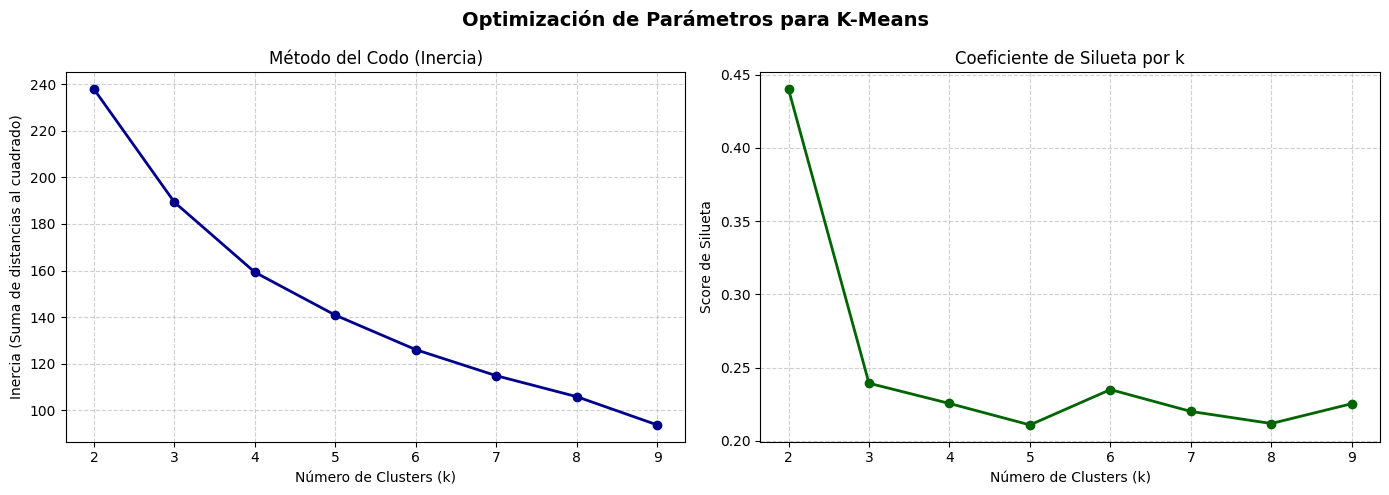

In [ ]:
from sklearn.cluster import KMeans

# 3. Determinación de K: Método del Codo y Coeficiente de Silueta
k_range = range(2, 10)
inercia = []
silueta = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    inercia.append(km.inertia_)
    silueta.append(silhouette_score(X_clust_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Codo
ax1.plot(k_range, inercia, 'o-', color='darkblue', lw=2)
ax1.set_title('Método del Codo (Inercia)', fontsize=12)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Suma de distancias al cuadrado)')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Silueta
ax2.plot(k_range, silueta, 'o-', color='darkgreen', lw=2)
ax2.set_title('Coeficiente de Silueta por k', fontsize=12)
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Score de Silueta')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Optimización de Parámetros para K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.2 Ajuste del Modelo K-Means (k = 3)

K=3 proporciona una agrupación clara y significativa en el contexto del fútbol:
- **Cluster 0 – Equipos Dominantes/Élite**: Alto volumen ofensivo, muchos tiros al arco y goles.
- **Cluster 1 – Media Tabla**: Estadísticas balanceadas y regulares.
- **Cluster 2 – Zona Baja / Perfil Físico**: Mayor volumen de faltas y tarjetas, menor producción ofensiva.

In [ ]:
# 4. Entrenamiento del modelo K-Means con k=3
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
team_stats['cluster'] = kmeans_final.fit_predict(X_clust_scaled)

print("Distribución de equipos por cluster:")
print(team_stats['cluster'].value_counts().sort_index())

Distribución de equipos por cluster:
cluster
0     6
1    22
2    18
Name: count, dtype: int64


## 6.3 Visualización PCA (2D)

Proyectamos el espacio multidimensional en 2 componentes principales (PCA) para poder
visualizar gráficamente cómo se agrupan los equipos.

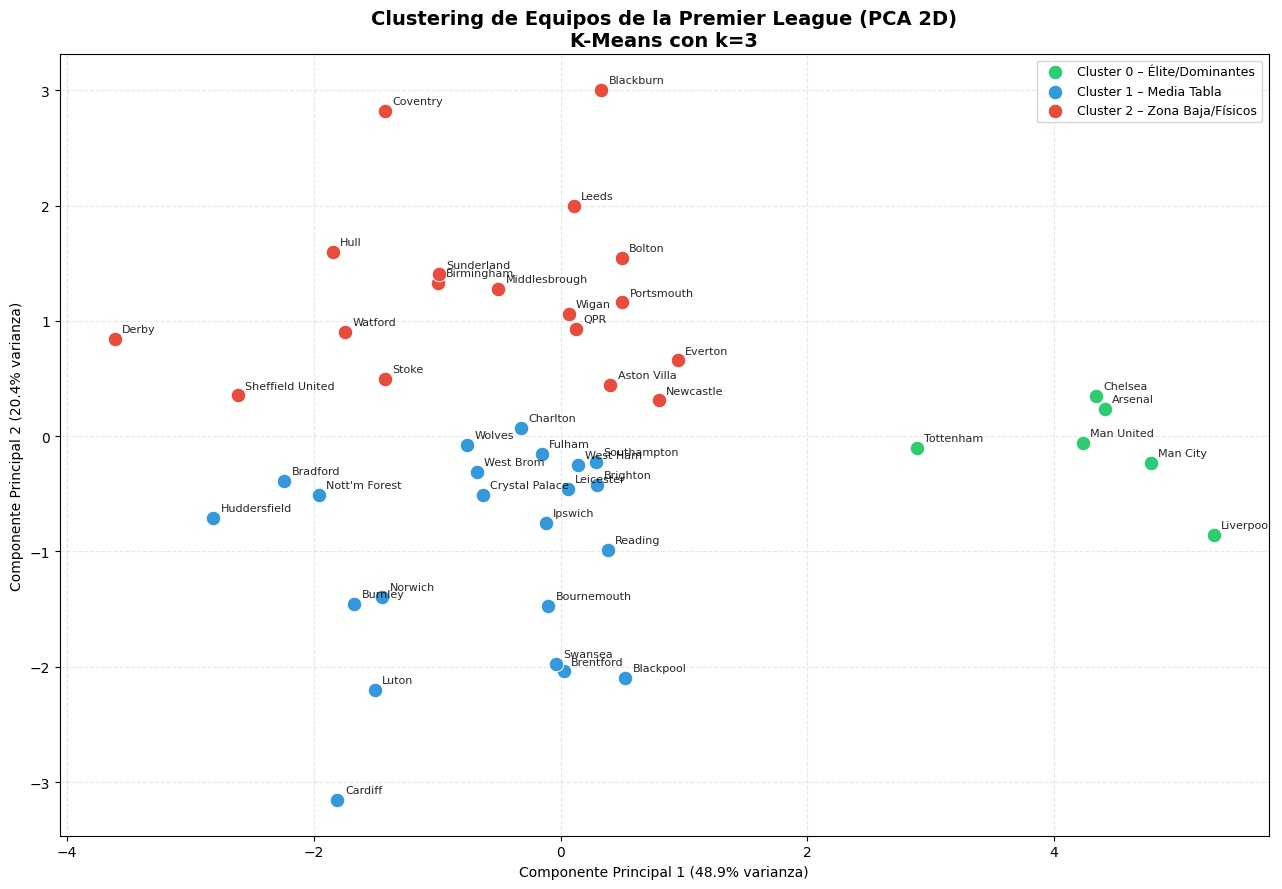

In [ ]:
# 5. Visualización de Clusters usando PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)
team_stats['pca_x'] = X_pca[:, 0]
team_stats['pca_y'] = X_pca[:, 1]

plt.figure(figsize=(13, 9))
colores_clusters = {0: '#2ecc71', 1: '#3498db', 2: '#e74c3c'}
cluster_labels_legend = {0: 'Cluster 0 – Élite/Dominantes', 1: 'Cluster 1 – Media Tabla', 2: 'Cluster 2 – Zona Baja/Físicos'}

for c in range(k_optimo):
    subset = team_stats[team_stats['cluster'] == c]
    plt.scatter(subset['pca_x'], subset['pca_y'],
                color=colores_clusters[c], s=110, label=cluster_labels_legend[c],
                edgecolors='white', linewidth=0.7, zorder=3)
    for team, row in subset.iterrows():
        plt.text(row['pca_x'] + 0.06, row['pca_y'] + 0.06, team, fontsize=8, alpha=0.85)

plt.title('Clustering de Equipos de la Premier League (PCA 2D)\nK-Means con k=3', fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.legend(loc='best', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 6.4 Perfilado de Clusters

Analizamos las estadísticas promedio de cada grupo para interpretar su significado futbolístico.

In [ ]:
# 6. Perfilado de Clusters: estadísticas promedio por grupo
print("=" * 65)
print("PERFIL PROMEDIO DE LOS CLUSTERS DE EQUIPOS (Premier League)")
print("=" * 65)
perfil = team_stats.groupby('cluster')[features_clust].mean().round(3)
print(perfil.to_string())

print()
print("=" * 65)
print("EQUIPOS POR CLUSTER")
print("=" * 65)
for c in range(k_optimo):
    equipos_c = sorted(team_stats[team_stats['cluster'] == c].index.tolist())
    print(f"\nCluster {c} ({len(equipos_c)} equipos):")
    print(", ".join(equipos_c))

PERFIL PROMEDIO DE LOS CLUSTERS DE EQUIPOS (Premier League)
         Goles_Favor_Promedio  Goles_Contra_Promedio  Tiros_Promedio  Tiros_Arco_Promedio  Corners_Promedio  Faltas_Promedio  Amarillas_Promedio  Rojas_Promedio
cluster                                                                                                                                                         
0                       1.821                  1.046          14.604                6.614             6.272           10.957               1.551           0.069
1                       1.149                  1.636          11.050                4.379             4.911           11.083               1.585           0.058
2                       1.083                  1.527          10.874                4.956             4.991           12.492               1.759           0.091

EQUIPOS POR CLUSTER

Cluster 0 (6 equipos):
Arsenal, Chelsea, Liverpool, Man City, Man United, Tottenham

Cluster 1 (22 equipos):
Blac

---
## Sección de Web Scraping (Datos 2025/26)

Extracción de partidos de la temporada 2025/26 desde la API de football-data.org.

In [ ]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "requests", "beautifulsoup4", "lxml", "-q"])

0

In [ ]:
import requests
import pandas as pd
import numpy as np

API_KEY = "86f3edc286ac476693a094974fa4e97f"

headers = {"X-Auth-Token": API_KEY}

# Traer todos los partidos de la temporada 2025-26
response = requests.get(
    "https://api.football-data.org/v4/competitions/PL/matches",
    headers=headers,
    params={"season": 2025}
)

data = response.json()

if "matches" not in data:
    print("Error:", data)
else:
    matches = data["matches"]
    print(f"Total partidos en la temporada: {len(matches)}")
    played = [m for m in matches if m["status"] == "FINISHED"]
    print(f"Partidos jugados hasta hoy: {len(played)}")

Total partidos en la temporada: 380
Partidos jugados hasta hoy: 380


In [ ]:
def get_result(h, a):
    if h > a: return "H"
    if h < a: return "A"
    return "D"

rows = []
for m in played:
    h = m["score"]["fullTime"]["home"]
    a = m["score"]["fullTime"]["away"]
    rows.append({
        "Season":            "2025/26",
        "MatchDate":         m["utcDate"][:10],
        "HomeTeam":          m["homeTeam"]["shortName"],
        "AwayTeam":          m["awayTeam"]["shortName"],
        "FullTimeHomeGoals": h,
        "FullTimeAwayGoals": a,
        "FullTimeResult":    get_result(h, a),
        "HalfTimeHomeGoals": m["score"]["halfTime"]["home"],
        "HalfTimeAwayGoals": m["score"]["halfTime"]["away"],
        "HalfTimeResult":    get_result(
                                m["score"]["halfTime"]["home"],
                                m["score"]["halfTime"]["away"]
                             ) if m["score"]["halfTime"]["home"] is not None else np.nan,
        # Stats no disponibles en plan gratuito
        "HomeShots":         np.nan, "AwayShots":         np.nan,
        "HomeShotsOnTarget": np.nan, "AwayShotsOnTarget": np.nan,
        "HomeCorners":       np.nan, "AwayCorners":       np.nan,
        "HomeFouls":         np.nan, "AwayFouls":         np.nan,
        "HomeYellowCards":   np.nan, "AwayYellowCards":   np.nan,
        "HomeRedCards":      np.nan, "AwayRedCards":      np.nan,
    })

new_df = pd.DataFrame(rows)
df_final = pd.concat([df, new_df], ignore_index=True)

print(f"Partidos nuevos: {len(new_df)}")
print(f"Total dataset: {len(df_final)}")
new_df.head()

Partidos nuevos: 380
Total dataset: 9760


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2025/26,2025-08-15,Liverpool,Bournemouth,4,2,H,1,0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025/26,2025-08-16,Aston Villa,Newcastle,0,0,D,0,0,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025/26,2025-08-16,Brighton Hove,Fulham,1,1,D,0,0,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025/26,2025-08-16,Sunderland,West Ham,3,0,H,0,0,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025/26,2025-08-16,Tottenham,Burnley,3,0,H,1,0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_final.to_csv("premier_league_2000_2026.csv", index=False)
print("Guardado como premier_league_2000_2026.csv")

Guardado como premier_league_2000_2026.csv


In [ ]:
import pickle
import os

model_filename = "tu_modelo.pkl"
if not os.path.exists(model_filename) and os.path.exists("modelo_pl.pkl"):
    model_filename = "modelo_pl.pkl"

if os.path.exists(model_filename):
    with open(model_filename, "rb") as f:
        model = pickle.load(f)
    print("Modelo cargado con exito desde:", model_filename)
    print("Tipo de modelo:", type(model))
    if hasattr(model, "feature_names_in_"):
        print("Features:", model.feature_names_in_)
    if hasattr(model, "classes_"):
        print("Clases:", model.classes_)
else:
    print(f"Advertencia: No se encontro el archivo de modelo '{model_filename}'.")

Modelo cargado con exito desde: modelo_pl.pkl
Tipo de modelo: <class 'sklearn.naive_bayes.GaussianNB'>
Features: ['home_home_win_rate_last5' 'home_home_avg_goals_for_last5'
 'home_home_avg_goals_against_last5' 'home_home_avg_sot_last5'
 'away_away_win_rate_last5' 'away_away_avg_goals_for_last5'
 'away_away_avg_goals_against_last5' 'away_away_avg_sot_last5'
 'h2h_avg_goal_diff']
Clases: [0 1 2]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianNB from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
